## **Table of Contents**

- [1 - Business Objective](#1-business-objective)
  - [1.1 - Context: Targeted Alpha Therapy (TAT)](#11-context-targeted-alpha-therapy-tat)
  - [1.2 - The Bottleneck: Isotope Screening](#12-the-bottleneck-isotope-screening)
  - [1.3 - The Cost Problem](#13-the-cost-problem)
  - [1.4 - Business Objective Statement](#14-business-objective-statement)
- [2 - Problem Statement](#2-problem-statement)
  - [2.1 - Formal Definition](#21-formal-definition)
  - [2.2 - The TAT Isotope Selection Problem](#22-the-tat-isotope-selection-problem)
  - [2.3 - The Input Variables](#23-the-input-variables)
  - [2.4 - The Target Variable](#24-the-target-variable)
  - [2.5 - The Baseline to Beat](#25-the-baseline-to-beat)
  - [2.6 - Success Criteria](#26-success-criteria)
- [3 - Solution Methodology](#3-solution-methodology)
  - [3.1 - Architecture & Workflow](#31-architecture-workflow)
  - [3.2 - Key Design Decisions](#32-key-design-decisions)
  - [3.3 - Important Note on Dataset Size](#33-important-note-on-dataset-size)
- [4 - A Brief History: From Rutherford to Machine Learning](#4-a-brief-history-from-rutherford-to-machine-learning)
  - [4.1 - 1900s: The Nuclear Problem: Before the Formula](#41-1900s-the-nuclear-problem-before-the-formula)
  - [4.2 - 1935: Bethe and Weizsäcker Write Down the First Formula](#42-1935-bethe-and-weizsäcker-write-down-the-first-formula)
  - [4.3 - 1950s-1990s: Decades of Refinement](#43-1950s-1990s-decades-of-refinement)
  - [4.4 - 2020: Machine Learning Enters the Picture](#44-2020-machine-learning-enters-the-picture)
  - [4.5 - March 2025: The Landmark Communications Physics Paper](#45-march-2025-the-landmark-communications-physics-paper)
  - [4.6 - Where We Are Today](#46-where-we-are-today)
- [5 - From Physics to Medicine: A History of Nuclear Medicine](#5-from-physics-to-medicine-a-history-of-nuclear-medicine)
  - [5.1 - Overview](#51-overview)
  - [5.2 - Stage 1: Discovery Era (1896-1930s): Radioactivity as a Physical Curiosity](#52-stage-1-discovery-era-1896-1930s-radioactivity-as-a-physical-curiosity)
  - [5.3 - Stage 2: I-131 and the Thyroid (1941): The First Therapeutic Radioisotope](#53-stage-2-i-131-and-the-thyroid-1941-the-first-therapeutic-radioisotope)
  - [5.4 - Stage 3: The Technetium-99m Revolution (1957-1990s): Diagnostic Nuclear Medicine Explodes](#54-stage-3-the-technetium-99m-revolution-1957-1990s-diagnostic-nuclear-medicine-explodes)
  - [5.5 - Stage 4: PET and FDG (1970s-2000s): Imaging Cancer's Metabolism](#55-stage-4-pet-and-fdg-1970s-2000s-imaging-cancers-metabolism)
  - [5.6 - Stage 5: Somatostatin Receptors & NETs: The Biological Pivot](#56-stage-5-somatostatin-receptors-nets-the-biological-pivot)
  - [5.7 - Stage 6: First PRRT Attempts (1990s-early 2000s): In-111 and Y-90](#57-stage-6-first-prrt-attempts-1990s-early-2000s-in-111-and-y-90)
  - [5.8 - Stage 7: The Lu-177 Breakthrough (early 2000s-2016): The Theranostic Ideal](#58-stage-7-the-lu-177-breakthrough-early-2000s-2016-the-theranostic-ideal)
  - [5.9 - Stage 8: NETTER-1 and the FDA (2014-2018)](#59-stage-8-netter-1-and-the-fda-2014-2018)
  - [5.10 - The ML Connection](#510-the-ml-connection)
- [6 - Installing and Importing the Libraries](#6-installing-and-importing-the-libraries)
  - [6.1 - Overview](#61-overview)
- [7 - Load the AME2020 Dataset](#7-load-the-ame2020-dataset)
  - [7.1 - What is AME2020?](#71-what-is-ame2020)
  - [7.2 - File format challenge](#72-file-format-challenge)
  - [7.3 - Understanding the Data Structure](#73-understanding-the-data-structure)
- [8 - Extended Nuclear Data: Half-Lives & Decay Modes](#8-extended-nuclear-data-half-lives-decay-modes)
  - [8.1 - Overview](#81-overview)
- [9 - SEMF: The Classical Baseline](#9-semf-the-classical-baseline)
  - [9.1 - Overview](#91-overview)
  - [9.2 - The five terms](#92-the-five-terms)
- [10 - Feature Engineering](#10-feature-engineering)
  - [10.1 - Overview](#101-overview)
- [11 - GenAI-Generated Features](#11-genai-generated-features)
  - [11.1 - Overview](#111-overview)
  - [11.2 - Calling the Free HF Router for Feature Suggestions](#112-calling-the-free-hf-router-for-feature-suggestions)
  - [11.3 - Constructing the AI-Suggested Features Safely](#113-constructing-the-ai-suggested-features-safely)
  - [11.4 - Ablation: Human Features vs AI Features vs Combined](#114-ablation-human-features-vs-ai-features-vs-combined)
  - [11.5 - Adopting the Combined Feature Set](#115-adopting-the-combined-feature-set)
- [12 - GenAI Synthetic Data Augmentation](#12-genai-synthetic-data-augmentation)
  - [12.1 - Overview](#121-overview)
  - [12.2 - Asking the LLM for Underrepresented Regions](#122-asking-the-llm-for-underrepresented-regions)
  - [12.3 - Generating Synthetic Rows from SEMF, Not from the LLM](#123-generating-synthetic-rows-from-semf-not-from-the-llm)
  - [12.4 - Three-Way Generalisation Check](#124-three-way-generalisation-check)
  - [12.5 - Reading the Result Honestly](#125-reading-the-result-honestly)
- [13 - Train ML Models](#13-train-ml-models)
  - [13.1 - Model 1: Random Forest](#131-model-1-random-forest)
  - [13.2 - Model 2: Histogram Gradient Boosting (HGB)](#132-model-2-histogram-gradient-boosting-hgb)
- [14 - Evaluate and Compare Models](#14-evaluate-and-compare-models)
  - [14.1 - Overview](#141-overview)
  - [14.2 - SHAP Feature Importance: What Does the Model Actually Learn?](#142-shap-feature-importance-what-does-the-model-actually-learn)
- [15 - A Light Deep Learning Model](#15-a-light-deep-learning-model)
  - [15.1 - Overview](#151-overview)
  - [15.2 - Architecture and Training](#152-architecture-and-training)
  - [15.3 - Comparing Against SEMF, Random Forest, and HGB](#153-comparing-against-semf-random-forest-and-hgb)
- [16 - Foundation Model Benchmark: TabPFN](#16-foundation-model-benchmark-tabpfn)
  - [16.1 - Overview](#161-overview)
  - [16.2 - Fitting TabPFN](#162-fitting-tabpfn)
  - [16.3 - Four-Way Comparison](#163-four-way-comparison)
- [17 - The Segrè Chart: Visualising the Nuclear Landscape](#17-the-segrè-chart-visualising-the-nuclear-landscape)
  - [17.1 - Overview](#171-overview)
- [18 - Stage A: Half-Life Prediction](#18-stage-a-half-life-prediction)
  - [18.1 - Overview](#181-overview)
- [19 - Stage B: Decay Mode Classification](#19-stage-b-decay-mode-classification)
  - [19.1 - Overview](#191-overview)
- [20 - Stage D: Composite Isotope Viability Score](#20-stage-d-composite-isotope-viability-score)
  - [20.1 - Overview](#201-overview)
  - [20.2 - Scoring Criteria](#202-scoring-criteria)
- [21 - Isotope Spotlights: Why These Four Win](#21-isotope-spotlights-why-these-four-win)
  - [21.1 - Overview](#211-overview)
  - [21.2 - Lutetium-177: The Theranostic Gold Standard](#212-lutetium-177-the-theranostic-gold-standard)
  - [21.3 - The Other Three: Why They Also Appear at the Top](#213-the-other-three-why-they-also-appear-at-the-top)
- [22 - Agentic Layer: From Fixed Pipeline to Autonomous Agent](#22-agentic-layer-from-fixed-pipeline-to-autonomous-agent)
  - [22.1 - Overview](#221-overview)
  - [22.2 - The Fixed Pipeline: Diagnose, Then Recommend](#222-the-fixed-pipeline-diagnose-then-recommend)
  - [22.3 - Running the Fixed Pipeline](#223-running-the-fixed-pipeline)
  - [22.4 - The Autonomous Agent Upgrade: A ReAct Pattern](#224-the-autonomous-agent-upgrade-a-react-pattern)
  - [22.5 - Defining the Agent's Tools and Memory](#225-defining-the-agents-tools-and-memory)
  - [22.6 - Building the ReAct Graph with a Conditional Edge](#226-building-the-react-graph-with-a-conditional-edge)
  - [22.7 - Running the Autonomous Agent](#227-running-the-autonomous-agent)
  - [22.8 - Fixed Pipeline vs Autonomous Agent](#228-fixed-pipeline-vs-autonomous-agent)
- [23 - Interactive Prediction](#23-interactive-prediction)
  - [23.1 - Overview](#231-overview)
  - [23.2 - Example 1: Iron-56 (the most tightly bound nucleus per nucleon in nature)](#232-example-1-iron-56-the-most-tightly-bound-nucleus-per-nucleon-in-nature)
  - [23.3 - Example 2: Lutetium-177 (the FDA-approved theranostic isotope for NETs)](#233-example-2-lutetium-177-the-fda-approved-theranostic-isotope-for-nets)
  - [23.4 - Example 3: An Exotic Nucleus (not yet fully characterised experimentally)](#234-example-3-an-exotic-nucleus-not-yet-fully-characterised-experimentally)
  - [23.5 - Your Turn: Explore the Full TAT Candidate Landscape](#235-your-turn-explore-the-full-tat-candidate-landscape)
  - [23.6 - Optional: Route Through the Autonomous Agent](#236-optional-route-through-the-autonomous-agent)
- [24 - Conclusion](#24-conclusion)
  - [24.1 - What we built: the full pipeline](#241-what-we-built-the-full-pipeline)
  - [24.2 - The headline result: binding energy](#242-the-headline-result-binding-energy)
  - [24.3 - The clinical validation: the pipeline surfaces the right isotopes](#243-the-clinical-validation-the-pipeline-surfaces-the-right-isotopes)
  - [24.4 - The theranostics imperative](#244-the-theranostics-imperative)
  - [24.5 - Perspectives: where this goes next](#245-perspectives-where-this-goes-next)
- [25 - Takeaways](#25-takeaways)
  - [25.1 - For the ML Practitioner](#251-for-the-ml-practitioner)
  - [25.2 - For the Radiopharmaceutical / Nuclear Medicine Professional](#252-for-the-radiopharmaceutical-nuclear-medicine-professional)
  - [25.3 - Key Numbers Across the Full Pipeline](#253-key-numbers-across-the-full-pipeline)
  - [25.4 - The Thread from Bethe to Lutathera](#254-the-thread-from-bethe-to-lutathera)

## **1 - Business Objective**

### **1.1 - Context: Targeted Alpha Therapy (TAT)**

**Targeted Alpha Therapy** is one of the fastest-growing areas of oncology. The core idea: **attach a radioactive isotope that emits alpha particles directly to a molecule that seeks out cancer cells.** Once bound to the tumour, the alpha particle delivers a lethal dose of radiation to the cell: while its short range (40-80 micrometres in tissue) spares surrounding healthy tissue.

The FDA approved **Lutetium-177 DOTATATE** (Lutathera) in 2018 for neuroendocrine tumours, opening the floodgates. The current clinical pipeline includes hundreds of TAT candidates, with isotopes like **Actinium-225, Bismuth-213, and Astatine-211** at various stages of trials. The global radiopharmaceutical market was valued at 6.5 billion USD in 2023 and is projected to exceed 15 billion USD by 2030.

### **1.2 - The Bottleneck: Isotope Screening**

Not every alpha-emitting isotope is clinically viable. A therapeutic candidate must satisfy several constraints simultaneously:

| Constraint | Why it matters |
|------------|---------------|
| **Half-life** | Long enough for delivery to the tumour (hours to days), short enough to limit patient dose |
| **Decay chain** | Daughter nuclei must not emit dangerous long-range radiation |
| **Production feasibility** | Must be producible in sufficient quantities in a cyclotron or reactor |
| **Binding energy stability** | Determines whether the nucleus is stable enough to survive transport and targeting |

All of these properties ultimately trace back to **nuclear binding energy**: the energy holding the nucleus together, which governs stability, decay mode, and half-life.

### **1.3 - The Cost Problem**

Synthesising a new isotope in a cyclotron costs **USD 50,000 to USD 500,000 per candidate** and requires weeks of accelerator time.

**Z is the number of protons in a nucleus; N is the number of neutrons.** Together they produce a nucleus that is more than the sum of its parts: nuclear forces bind the nucleons tightly while the electrostatic repulsion of those protons pushes outward, and the balance of these two forces varies with every (Z, N) pair. Different combinations achieve different levels of stability, and understanding which combinations bind tightly enough to be useful is, in many ways, the whole art and science of Nuclear Physics.

The limiting step is not chemistry or biology - it is the physics screening: determining which (Z, N) combinations are stable enough, have the right half-life, and decay cleanly.

Today this screening is done experimentally or with expensive physics simulations. A well-calibrated ML model that predicts binding energy from Z and N alone can **pre-screen thousands of candidates computationally before a single gram of material is produced.**

### **1.4 - Business Objective Statement**

> **Build a machine learning model that, given only the proton count (Z) and neutron count (N) of an atomic nucleus, predicts its binding energy per nucleon with sufficient accuracy to rank and filter candidate isotopes for Targeted Alpha Therapy - reducing the experimental screening cost per viable therapeutic isotope.**

<a id="2-problem-statement"></a>

## **2 - Problem Statement**

### **2.1 - Formal Definition**

> **Given only the integer pair (Z, N): the proton count and neutron count of an atomic nucleus: predict its binding energy per nucleon (MeV) with sufficient accuracy to distinguish viable Targeted Alpha Therapy isotope candidates from unstable ones, without requiring experimental synthesis.**

### **2.2 - The TAT Isotope Selection Problem**

In clinical practice, a TAT isotope must meet a narrow window of binding energy criteria:

- **Too loosely bound** (BE/A < ~5 MeV): nucleus is highly unstable, will decay too fast for clinical use
- **Too tightly bound** (BE/A > ~8.5 MeV): nucleus is stable and will *not* decay: useless as a therapeutic
- **The sweet spot**: **alpha-emitting isotopes typically sit in the 6-8 MeV/A** range, with half-lives of minutes to days

So the Machine Learning model we build must be accurate enough to correctly classify a nucleus into one of these zones from Z and N alone.

### **2.3 - The Input Variables**

Every nucleus is completely specified by two integers:

| Symbol | Name | Meaning |
|--------|------|---------|
| **Z** | Atomic number | Number of protons: determines which *element* it is |
| **N** | Neutron number | Number of neutrons: determines which *isotope* of that element |
| **A = Z + N** | Mass number | Total nucleon count |

There is no other fundamental input. The binding energy is a consequence of quantum mechanics applied to Z protons and N neutrons.

### **2.4 - The Target Variable**

**Binding Energy per Nucleon (BE/A)**: measured in **MeV (Megaelectronvolts)**

| Regime | BE/A range | Clinical interpretation |
|--------|-----------|------------------------|
| Very weakly bound | < 5 MeV/A | Exotic / unmeasured; often too short-lived |
| **Therapeutically interesting alpha emitters** | **~6-8 MeV/A** | **Candidate window for TAT** |
| Stable valley | ~8-8.8 MeV/A | Too stable: won't decay |

### **2.5 - The Baseline to Beat**

The **Bethe-Weizsäcker Semi-Empirical Mass Formula (SEMF)**, derived in 1935, achieves an **RMSE of ~0.32 MeV** on the AME2020 dataset.

**This was the state of the art for six decades.**

Our goal is to demonstrate that modern ML models beat it, thereby enabling finer-grained isotope screening.

### **2.6 - Success Criteria**

| Metric | SEMF baseline | ML target |
|--------|--------------|-----------|
| RMSE (MeV/A) | 0.32 | **< 0.15** |
| MAE (MeV/A) | 0.09 | **< 0.05** |
| Practical benefit | Cannot resolve ~0.3 MeV differences | **Can distinguish isotopes separated by 0.1 MeV: meaningful for half-life prediction** |


<a id="3-solution-methodology"></a>

## **3 - Solution Methodology**

### **3.1 - Architecture & Workflow**

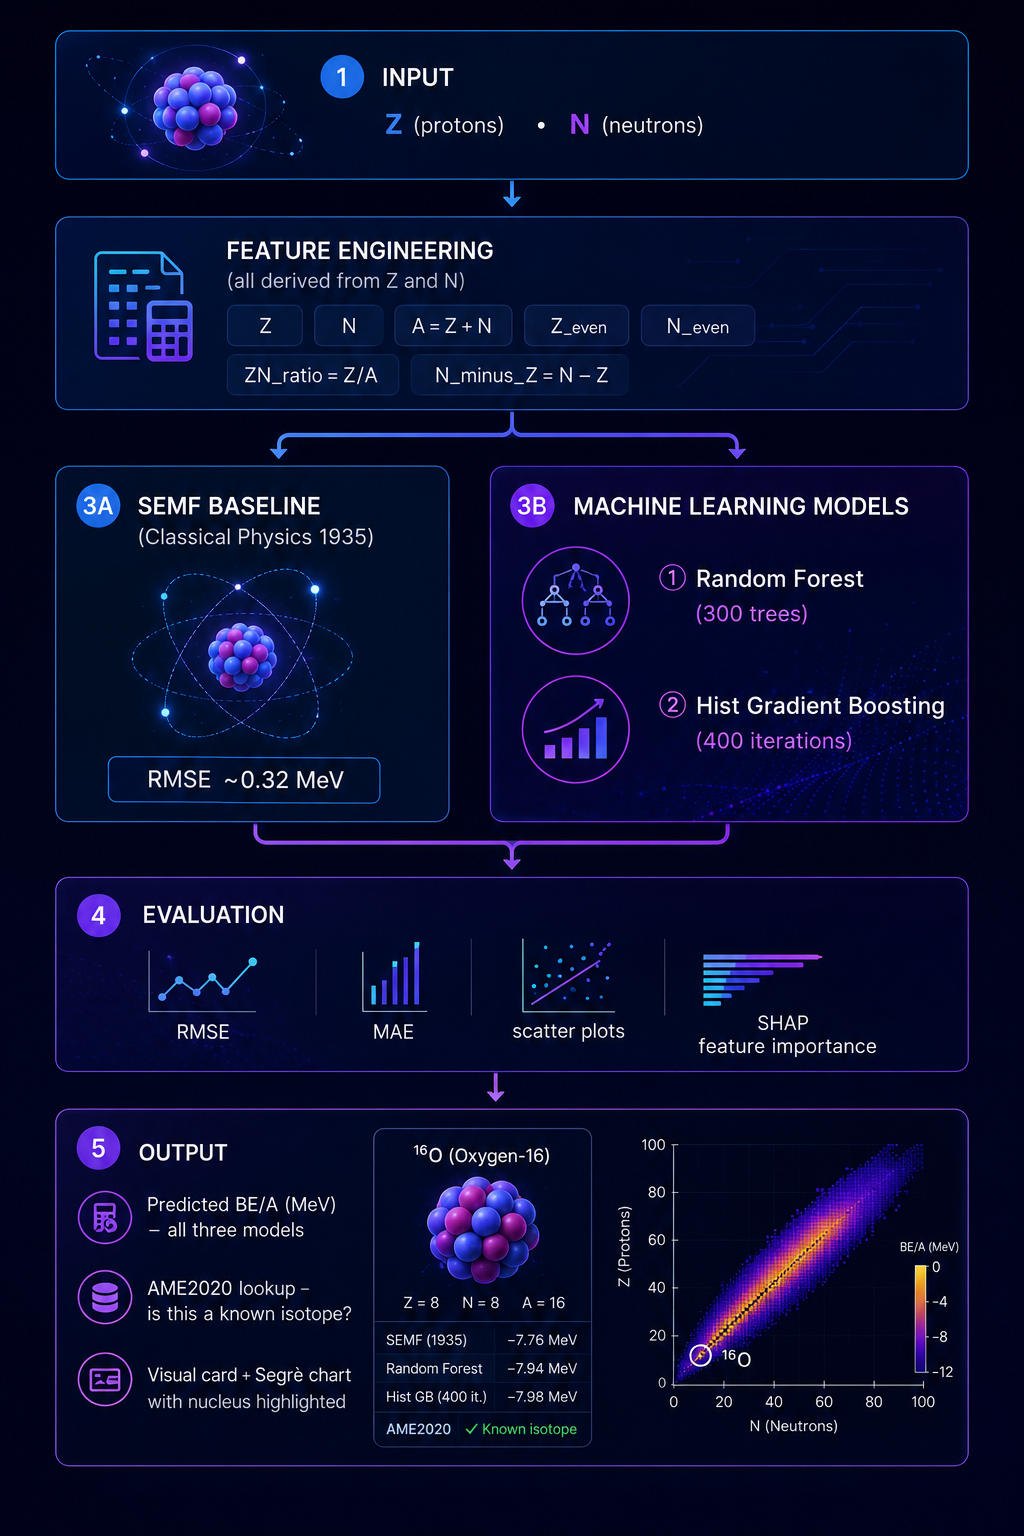


```
┌─────────────────────────────────────────────────────────────────────┐
│  INPUT                                                              │
│  Z (protons)  ·  N (neutrons)                                       │
└──────────────────────┬──────────────────────────────────────────────┘
                       │
                       ▼
┌─────────────────────────────────────────────────────────────────────┐
│  FEATURE ENGINEERING  (all derived from Z and N)                    │
│  Z, N, A=Z+N, Z_even, N_even, ZN_ratio=Z/A, N_minus_Z=N-Z         │
└──────────────────────┬──────────────────────────────────────────────┘
                       │
          ┌────────────┴────────────┐
          │                         │
          ▼                         ▼
┌──────────────────┐     ┌──────────────────────────────┐
│  SEMF BASELINE   │     │  MACHINE LEARNING MODELS      │
│  (Classical      │     │                               │
│   Physics 1935)  │     │  ① Random Forest (300 trees) │
│                  │     │  ② Hist Gradient Boosting     │
│  RMSE ~0.32 MeV  │     │     (400 iterations)          │
└──────────────────┘     └──────────────────────────────┘
          │                         │
          └────────────┬────────────┘
                       │
                       ▼
┌─────────────────────────────────────────────────────────────────────┐
│  EVALUATION                                                         │
│  RMSE · MAE · scatter plots · SHAP feature importance              │
└──────────────────────┬──────────────────────────────────────────────┘
                       │
                       ▼
┌─────────────────────────────────────────────────────────────────────┐
│  OUTPUT                                                             │
│  · Predicted BE/A (MeV): all three models                         │
│  · AME2020 lookup: is this a known isotope?                        │
│  · Visual card + Segrè chart with nucleus highlighted              │
└─────────────────────────────────────────────────────────────────────┘
```


### **3.2 - Key Design Decisions**

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Feature set | 7 features from Z, N | Minimal inputs; no domain knowledge required |
| Parity flags | Z_even, N_even | Captures quantum pairing without encoding the formula |
| Models | RF + HGB | Interpretable (SHAP), fast, no GPU required |
| Baseline | SEMF | Concrete, historically validated, can be coded |
| Dataset | AME2020 | IAEA-authoritative, 3,554 nuclides, freely downloadable |

### **3.3 - Important Note on Dataset Size**

**AME2020 has only ~3,500 rows.**

This is intentionally small - it is the **entire experimentally known nuclear chart**.

There is no more data to collect. This makes it an ideal dataset for learning (fits in RAM, no cloud needed), but also means the ML models must generalise from limited samples to exotic unmeasured nuclei.

<a id="4-a-brief-history"></a>

## **4 - A Brief History: From Rutherford to Machine Learning**

### **4.1 - 1900s: The Nuclear Problem: Before the Formula**

In the early 20th century, physicists faced a profound mystery. Ernest Rutherford's 1911 gold-foil experiment had established that the atom's mass is concentrated in a tiny, dense **nucleus**. Henry Moseley's X-ray spectroscopy experiments in 1913 then established that each element's atomic number equals the exact number of positive charges in its nucleus: hydrogen carries one proton, helium two, carbon six, uranium ninety-two. James Chadwick's 1932 experiments then identified a second nuclear constituent: the neutron, a particle with roughly the same mass as a proton but no electric charge. That same year, Werner Heisenberg proposed the proton-neutron model of the nucleus: the nucleus is not a cluster of protons alone, but a tightly packed assembly of positively-charged protons and electrically neutral neutrons. But if both types of particle are packed together at such close range, **why doesn't the assembly fly apart?** Protons should repel each other electrostatically on account of holding the same type of charge. So something else - something far stronger at short range: must be overpowering the electrostatic repulsion and holding them together.

This *something* came to be called the **strong nuclear force**. But measuring it directly was impossible at the time; what physicists *could* measure was the **mass** of a nucleus. And mass, through Einstein's E = mc², directly encodes the energy stored in that nuclear glue. The difference between the actual total measured nuclear mass, and the sum of its individual parts - the free proton and neutron masses, is what's known in Nuclear Physics as the **binding energy**: the energy that holds the nucleus together, and hence, the energy that you would need to supply to completely disassemble the nucleus.

### **4.2 - 1935: Bethe and Weizsäcker Write Down the First Formula**

By the early 1930s, James Chadwick had discovered the neutron (1932), and physicists had a new model: the nucleus as a **liquid drop** of protons and neutrons held together by the strong force. Carl Friedrich von Weizsäcker (1935) and Hans Bethe (1936) independently used this analogy to write down what we now call the **Semi-Empirical Mass Formula (SEMF)**:

$$BE = a_V A - a_S A^{2/3} - a_C \frac{Z(Z-1)}{A^{1/3}} - a_A \frac{(A-2Z)^2}{A} \pm \delta$$

| Term | Symbol | Physical meaning |
|------|--------|-----------------|
| Volume | $a_V A$ | Interior nucleons bind to all nearest neighbours |
| Surface | $-a_S A^{2/3}$ | Surface nucleons have fewer neighbours |
| Coulomb | $-a_C Z(Z-1)/A^{1/3}$ | Proton-proton electrostatic repulsion |
| Asymmetry | $-a_A(A-2Z)^2/A$ | Pauli exclusion disfavours large N−Z |
| Pairing | $\pm \delta / \sqrt{A}$ | Quantum pairing: even-even nuclei extra stable |

This was a **first quantitative result** of 1935. With just five fitted parameters, the formula predicts binding energies across the entire nuclear chart with **RMSE around 3 MeV.** It was the first quantitative model of nuclear structure.

### **4.3 - 1950s-1990s: Decades of Refinement**

Physicists spent the following six decades improving the SEMF in two directions:

**1. Shell Corrections (Strutinsky Method, 1967)**: Nucleons fill discrete quantum energy shells just like electrons in an atom. At *magic numbers* of protons or neutrons (2, 8, 20, 28, 50, 82, 126), shells are completely filled and the nucleus gains extra binding energy. The SEMF misses this entirely. Strutinsky's microscopic-macroscopic method adds shell corrections on top of the liquid-drop model, **reducing the RMSE to ~0.7 MeV**.

**2. Hartree-Fock and the Nuclear Density Functional Theory (1970s-2000s)**: Full quantum mechanical calculations using effective nucleon-nucleon interactions. These are extremely computationally expensive (hours per nucleus on supercomputers) but achieve an **RMSE ~0.5 MeV**. The Brussels-Montreal Skyrme-force models (HFB series) represented the state of the art as of the 2010s.

By 2020, the best pure-physics model for nuclear masses achieves RMSE **around 0.5 MeV** and requires either fitted shell corrections or intensive quantum mechanical calculations.

### **4.4 - 2020: Machine Learning Enters the Picture**

**The first systematic ML applications to nuclear masses** appeared from 2017 and continued into the 2020s, motivated by the release of AME2016 and then AME2020 datasets with ~3,400 well-measured nuclides.

**Key Results:**

| Year | Study | Model | RMSE |
|------|-------|-------|------|
| 2020 | Utama & Piekarewicz | Bayesian Neural Network | ~0.5 MeV |
| 2021 | Niu & Liang | CNN on nuclear chart image | ~0.3 MeV |
| 2022 | Various | Random Forest + AME2020 | ~0.2 MeV |
| 2023 | Generalized Additive Models | GAM on AME2020 | ~0.3 MeV |
| 2023 | Shang et al. | BWNN (physics-informed NN) | ~0.1 MeV |


But the pattern was consistent: **ML models trained on (Z, N) alone outperformed the classical SEMF** and approached the accuracy of far more expensive physics calculations.

### **4.5 - March 2025: The Landmark Communications Physics Paper**

The most dramatic result came in a paper published in **Communications Physics** (Nature portfolio) in March 2025:

> *"Rediscovering nuclear physics from data: symbolic machine learning extracts binding energy relations"*

The authors used **symbolic regression** (an ML technique that searches for mathematical expressions rather than fitting weights) on the AME2020 dataset. The algorithm was given Z and N and told to find the simplest analytical formula that fits the data.

The result: the algorithm independently **rediscovered the structure of the SEMF** from data alone, without being told anything about the liquid-drop model, the strong force, or nuclear physics. It found the volume, surface, Coulomb, and asymmetry terms from first principles. Beyond that, it found *additional terms* that physics had not included, achieving precision comparable to state-of-the-art nuclear models developed over decades.

This is one of the clearest demonstrations to date of **Machine Learning performing scientific discovery.**

### **4.6 - Where We Are Today**

The field has settled on a hybrid picture: Physics-informed ML models that use the SEMF as a feature or prior, then correct its residuals with a data-driven model.

This is exactly the architecture we implement in this notebook: **code the SEMF, measure its failures, then train ML on those failures**.

<a id="5-nuclear-medicine-history"></a>

## **5 - From Physics to Medicine: A History of Nuclear Medicine**

### **5.1 - Overview**

The physics we just traced: radioactive decay, binding energy, half-lives: did not stay in the laboratory. Over eight decades, it was progressively translated into one of the most precise cancer therapies ever developed. Here is that journey.

### **5.2 - Stage 1: Discovery Era (1896-1930s): Radioactivity as a Physical Curiosity**

Henri Becquerel discovered radioactivity in 1896. Marie Curie isolated polonium and radium, coined the term *radioactivity*, and demonstrated that radiation was an atomic property. Ernest Rutherford distinguished alpha, beta, and gamma radiation and showed that radioactive decay transforms one element into another. Frédéric and Irène Joliot-Curie took the decisive step in 1934: they demonstrated **artificial radioactivity**: that you could bombard a stable nucleus with particles and make it radioactive. That discovery made nuclear medicine possible, because you no longer had to mine naturally radioactive elements.

Ernest Lawrence invented the cyclotron at UC Berkeley (1930-32), a particle accelerator that produces radioisotopes on demand. George de Hevesy articulated the **radiotracer principle**: a radiolabeled molecule participates in biological processes without altering them, because a radioactive atom is chemically identical to its stable counterpart. This is the conceptual foundation of every nuclear medicine procedure ever performed.

### **5.3 - Stage 2: I-131 and the Thyroid (1941): The First Therapeutic Radioisotope**

In 1941, Saul Hertz administered MIT cyclotron-produced radioactive iodine to the first patient with hyperthyroidism. The reasoning was elegant: the thyroid concentrates iodine to make thyroid hormones. Administer radioactive iodine and the thyroid takes it up selectively: the radiation then destroys overactive or malignant thyroid tissue from within. This was the founding case study of nuclear medicine: **use the body's own biochemistry to deliver radiation precisely where you want it**.

The FDA approved sodium iodide I-131 for thyroid disease in 1951: the first-ever approved radiopharmaceutical. I-131 remains in use today for thyroid cancer. From Hertz's first patient to FDA approval: 10 years. Compare this to Lutathera: first patient ~2000 to FDA approval 2018: 18 years. The regulatory bar had risen substantially.

### **5.4 - Stage 3: The Technetium-99m Revolution (1957-1990s): Diagnostic Nuclear Medicine Explodes**

Arguably the most important single development in the history of nuclear medicine. Walter Tucker and Margaret Greene developed the first Tc-99m generator at Brookhaven National Laboratory in 1957. The genius was engineering: molybdenum-99 (t½ = 66 hours) decays into Tc-99m (t½ = 6 hours). Pack Mo-99 onto a column, periodically wash with saline, and you elute pure Tc-99m. The hospital receives a generator and "milks" fresh Tc-99m every morning: no on-site cyclotron or reactor needed.

Paul Harper at the University of Chicago demonstrated the effectiveness of Tc-99m for imaging the liver, brain, and thyroid. **Tc-99m now accounts for ~80% of all nuclear medicine procedures worldwide.** The 6-hour half-life is ideal for same-day imaging. The 140 keV gamma perfectly matches Anger-camera detectors. Tc-99m can be attached to dozens of different molecules, each targeting a different organ.

The diagnostic revolution of this era was critical for therapeutic nuclear medicine in a subtle way: it built the clinical infrastructure: the imaging equipment, the radiopharmacies, the trained physicians and medical physicists, the regulatory frameworks: that therapeutic applications would later inherit.

### **5.5 - Stage 4: PET and FDG (1970s-2000s): Imaging Cancer's Metabolism**

Positron Emission Tomography emerged from the physics of positron-electron annihilation: two 511 keV gamma rays travelling in exactly opposite directions. Detect both simultaneously and you can pinpoint the source with extraordinary precision. F-18 FDG (fluorodeoxyglucose) became the defining radiopharmaceutical: cancer cells consume glucose at dramatically elevated rates (the Warburg effect), and F-18 FDG: a glucose analog that gets trapped inside metabolically active cells: shows every active tumour in the body in a single scan. F-18's 110-minute half-life required a network of cyclotron facilities and PET centres globally. That same infrastructure later became the delivery mechanism for **Ga-68 DOTATATE**, the diagnostic partner of Lu-177 DOTATATE.

### **5.6 - Stage 5: Somatostatin Receptors & NETs: The Biological Pivot**

This is where the story shifts from physics and chemistry to biology: and where the door to Lutathera opens.

**Neuroendocrine tumours (NETs)** are slow-growing cancers arising from hormone-producing cells in the gut, pancreas, and lungs. They are rare (~2 per 100,000/year), often metastatic at diagnosis, and historically had no effective systemic treatment. Five-year survival for metastatic disease: ~19%.

The critical biological discovery: NETs **overexpress somatostatin receptor subtype 2 (SSTR2)** at levels enormously higher than normal tissue. Novartis developed **octreotide** in the 1980s: a synthetic somatostatin analog that binds SSTR2 with high affinity, controlling symptoms of functional NETs.

Eric Krenning's group at Erasmus Medical Centre in Rotterdam saw the obvious question: if NETs express huge amounts of SSTR2, and octreotide binds to SSTR2, **what happens if you attach a radioactive atom to octreotide?** By 1990 they had developed indium-111-labeled DTPA-octreotide (OctreoScan). Detection rate for well-differentiated NETs exceeded 90%. You could now see NETs across the whole body in a single scan.

### **5.7 - Stage 6: First PRRT Attempts (1990s-early 2000s): In-111 and Y-90**

The next step was obvious: use a higher-energy radionuclide for therapy with the same targeting molecule. In-111-DTPA-octreotide was tried first. It often induced symptom relief, but **Auger electrons have a range of only a few cell diameters**: too little energy for real tumour regression.

The field pivoted to **Y-90**, a high-energy pure beta emitter. A better chelator was developed: **DOTA**, which held the radiometal onto the peptide far more stably than DTPA. Y-90 DOTATOC and DOTATATE clinical trials ran across Europe through the 1990s and early 2000s. Y-90 worked: tumour regression ≥50% in 9-33% of patients. But Y-90 has a **fatal problem for the theranostic vision: it is a pure beta emitter**. You cannot image it directly. To see where the drug went, physicians used a completely separate In-111 OctreoScan: a different molecule with no guarantee of identical distribution. You were imaging with one drug and treating with another.

This is the precise moment where **Lu-177's nuclear physics properties became decisive**.

### **5.8 - Stage 7: The Lu-177 Breakthrough (early 2000s-2016): The Theranostic Ideal**

Lu-177 (Z=71, N=106, t½ = 6.647 days) emits:
- **Beta-minus radiation** with a maximum tissue range of ~2 mm: ideal therapy: deep enough for crossfire cell killing, shallow enough to spare surrounding tissue
- **Gamma rays at 113 keV and 208 keV**: imageable with a standard gamma camera

This means a patient receiving Lu-177 DOTATATE **can be scanned immediately after administration with the same atom doing the treating**. The therapeutic and imaging functions are inseparable. Physicians can measure where the drug actually went, calculate absorbed dose to tumour vs. kidney vs. bone marrow, and adjust subsequent cycles. This is **personalised dosimetry**: something Y-90 DOTATOC could never achieve.

Krenning's group at Erasmus began treating patients with Lu-177 DOTATATE in the early 2000s under compassionate access. The results were decisive:
- Complete remissions: 2% of patients
- Partial remissions: 28%
- Stable disease: 35%
- Median progression-free survival: **33 months** (vs. ~12 months historical)

The indirect Yb-176 neutron-capture production route (Yb-176 → Yb-177 → Lu-177, no stable lutetium present) yielded **no-carrier-added Lu-177** with specific activity high enough to radiolabel DOTATATE efficiently at clinical doses.

### **5.9 - Stage 8: NETTER-1 and the FDA (2014-2018)**

Advanced Accelerator Applications (AAA) funded the pivotal Phase III trial: **NETTER-1**. 229 patients with progressive midgut neuroendocrine tumours were randomised to Lu-177 DOTATATE or high-dose octreotide (then standard of care).

> **Median PFS: not reached (Lu-177 arm) vs. 8.5 months (control). Hazard ratio: 0.21.**

A hazard ratio of 0.21: a **79% reduction in risk of progression or death**: is exceptional by any oncology standard.

The companion diagnostic, Ga-68 DOTATATE (NetSpot), was FDA-approved in **2016**: ensuring the patient-selection infrastructure was in place two years before the drug itself.

**On January 26, 2018**, the FDA approved **Lutathera (lutetium Lu-177 dotatate)** for somatostatin receptor-positive gastroenteropancreatic NETs in adults. European approval had followed in September 2017. It was the first Peptide Receptor Radionuclide Therapy (PRRT) approved in the United States.

Novartis acquired AAA for ~$3.9 billion in 2018. The same platform principle: targeting molecule + chelator + therapeutic radiometal: was immediately applied to prostate cancer (PSMA target). **Lu-177 PSMA-617 (Pluvicto)** received FDA approval in 2022.

### **5.10 - The ML Connection**

Every stage of this journey involved a question that ML can now approach computationally:
- *Which unexplored isotopes sit in the therapeutic half-life window?* → **Half-Life Prediction Model**
- *Which emit both therapy radiation and imageable gamma?* → **Decay Mode Classifier**
- *Which can be produced at clinically useful quantities?* → **Production Yield Estimator**
- *Which bond stably to DOTA-like chelators?* → **Molecular property model**

The Lu-177 story is, in retrospect, a very expensive search through a parameter space that ML can now navigate systematically. The next-generation TAT candidates: Ac-225, Bi-213, At-211: are exactly what an ML-guided isotope viability pipeline would surface and rank. **That search is already underway, and we build a version of it in this notebook.**

<a id="6-imports"></a>

## **6 - Installing and Importing the Libraries**

### **6.1 - Overview**

In [ ]:
# ── Environment detection ──────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
    print("Running on: Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running on: Local Jupyter")

# ── Install shap (not pre-installed on Colab; safe no-op if already present) ─
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=True)
print("shap: ready")

# ── Data download: tries multiple sources in order ────────────────────
#
#   Source 1: IAEA NDS  (AME2020, ~3554 nuclides, fixed-width .txt)
#             Blocked by some cloud IPs (GCP/Colab): tried with browser UA first.
#   Source 2: GitHub / project-ida  (AME2016 clean CSV, ~2511 nuclides)
#             Hosted on GitHub raw CDN: accessible everywhere.
#
import os, requests

os.makedirs("data", exist_ok=True)

SOURCES = [
    {
        "name":   "IAEA NDS: AME2020 (fixed-width)",
        "url":    "https://nds.iaea.org/amdc/ame2020/mass_1.mas20.txt",
        "dest":   os.path.join("data", "mass_1.mas20.txt"),
        "format": "ame2020",
    },
    {
        "name":   "GitHub / project-ida: AME2016 (clean CSV, fallback)",
        "url":    "https://raw.githubusercontent.com/project-ida/nuclear-reactions/master/data/binding-energies-iaea.csv",
        "dest":   os.path.join("data", "binding_energies.csv"),
        "format": "csv",
    },
]

DATA_FILE   = None
DATA_FORMAT = None
BROWSER_UA  = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
               "AppleWebKit/537.36 (KHTML, like Gecko) "
               "Chrome/124.0 Safari/537.36")

for src in SOURCES:
    if os.path.exists(src["dest"]):
        DATA_FILE, DATA_FORMAT = src["dest"], src["format"]
        print(f"Data file already present: {DATA_FILE}  (format: {DATA_FORMAT})")
        break
    try:
        print(f"Trying {src['name']} ...")
        r = requests.get(src["url"],
                         headers={"User-Agent": BROWSER_UA},
                         timeout=30)
        r.raise_for_status()
        with open(src["dest"], "wb") as f:
            f.write(r.content)
        DATA_FILE, DATA_FORMAT = src["dest"], src["format"]
        print(f"  Downloaded: {src['dest']}  ({len(r.content):,} bytes)")
        break
    except Exception as e:
        print(f"  Failed: {e}")

if DATA_FILE is None:
    raise RuntimeError(
        "All download sources failed.\n"
        "Manual fix: upload mass_1.mas20.txt to the data/ folder, then re-run."
    )

print(f"\nDataset : {DATA_FILE}")
print(f"Format  : {DATA_FORMAT}  "
      f"({'AME2020 ~3554 nuclides' if DATA_FORMAT == 'ame2020' else 'AME2016 ~2511 nuclides: fallback'})")


All libraries used are open-source and available via pip. If you haven't installed them:
```bash
pip install pandas numpy scikit-learn matplotlib shap jupyter
```


In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_FILE = os.path.join("data", "mass_1.mas20.txt")
print(f"Libraries loaded successfully.")
print(f"AME2020 file present: {os.path.exists(DATA_FILE)}")


<a id="7-load-data"></a>

## **7 - Load the AME2020 Dataset**

### **7.1 - What is AME2020?**

The **Atomic Mass Evaluation 2020** is the authoritative global dataset of nuclear masses, published by the International Atomic Energy Agency (IAEA) and maintained by the Atomic Mass Data Center (AMDC). It is updated roughly every five years as new experimental measurements are collected worldwide.

- **3,588 nuclides** measured or estimated
- Covers **Z = 0 to 118**, **A = 1 to 295**
- Values sourced from ~20,000 experimental measurements worldwide
- Key columns: N, Z, A, element symbol, mass excess (keV), binding energy/nucleon (keV)


### **7.2 - File format challenge**


The file is a **Fortran fixed-width ASCII table**: a format common in scientific computing since the 1960s. Two special characters must be handled:

| Character | Meaning | Action |
|-----------|---------|--------|
| `#` | Replaces the decimal point for *estimated* (non-experimental) values | Replace with `.` |
| `*` | Value cannot be calculated | Replace with `NaN` |

In [ ]:
def _clean(raw):
    """
    Convert a raw AME2020 fixed-width field to float.
    '#' replaces the decimal point for estimated values.
    '*' marks uncalculable quantities -> NaN.
    """
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip()
    if not s or "*" in s:
        return np.nan
    return float(s.replace("#", "."))


def load_ame2020(filepath=DATA_FILE):
    """
    Parse the AME2020 mass table (mass_1.mas20.txt).

    Fortran format string from file header:
    a1,i3,i5,i5,i5,1x,a3,a4,1x,f14.6,f12.6,f13.5,1x,f10.5,...
       NZ  N  Z  A      EL  O   mass_exc  unc   BE/A   unc

    Column byte ranges (0-indexed, end exclusive):
    NZ: 1-4  |  N: 4-9  |  Z: 9-14  |  A: 14-19  |
    EL: 20-23  |  MASS_EXC: 28-42  |  BE/A: 54-67
    """
    with open(filepath) as f:
        lines = f.readlines()

    # Data begins two lines after the '1N-Z ...' column-header line
    skip = 0
    for i, line in enumerate(lines):
        if "1N-Z" in line:
            skip = i + 2
            break

    colspecs = [(1,4),(4,9),(9,14),(14,19),(20,23),(28,42),(54,67)]
    cols     = ["NZ","N","Z","A","EL","mass_exc_raw","be_a_raw"]

    df = pd.read_fwf(filepath, colspecs=colspecs, names=cols,
                     skiprows=skip, dtype=str)

    for c in ["N","Z","A"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["EL"]           = df["EL"].str.strip()
    df["mass_exc_kev"] = df["mass_exc_raw"].apply(_clean)
    df["be_a_kev"]     = df["be_a_raw"].apply(_clean)
    df["be_a_mev"]     = df["be_a_kev"] / 1000.0

    df = df.dropna(subset=["N","Z","A","be_a_kev"])
    df = df[(df["A"] > 1) & (df["be_a_kev"] > 0)]
    df[["N","Z","A"]] = df[["N","Z","A"]].astype(int)

    # Derived features: all computable from Z and N
    df["Z_even"]    = (df["Z"] % 2 == 0).astype(int)
    df["N_even"]    = (df["N"] % 2 == 0).astype(int)
    df["ZN_ratio"]  = df["Z"] / df["A"]
    df["N_minus_Z"] = df["N"] - df["Z"]

    return df.reset_index(drop=True)


df = load_ame2020()
print(f"Loaded {len(df):,} nuclides  |  Z: {df['Z'].min()}-{df['Z'].max()}  |  A: {df['A'].min()}-{df['A'].max()}")


### **7.3 - Understanding the Data Structure**

In [ ]:
print("Dataset shape:", df.shape)
print()
print("Sample rows:")
display(df[["Z","N","A","EL","mass_exc_kev","be_a_kev","be_a_mev","Z_even","N_even"]].head(10))


In [ ]:
print("Summary statistics for binding energy per nucleon (MeV):")
print(df["be_a_mev"].describe().round(4))
print()
most_bound = df.loc[df["be_a_mev"].idxmax()]
print(f"Most tightly bound nucleus: {most_bound['EL']}-{most_bound['A']:g}  "
      f"(Z={most_bound['Z']:g}, N={most_bound['N']:g})  "
      f"BE/A = {most_bound['be_a_mev']:.4f} MeV")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. BE/A distribution
axes[0].hist(df["be_a_mev"], bins=60, color="#3b82f6", edgecolor="white", linewidth=0.3)
axes[0].axvline(df["be_a_mev"].max(), color="red", linestyle="--", lw=1.5,
                label=f"Max: {df['be_a_mev'].max():.2f} MeV")
axes[0].set_xlabel("Binding Energy per Nucleon (MeV)", fontsize=11)
axes[0].set_ylabel("Number of Nuclides", fontsize=11)
axes[0].set_title("BE/A Distribution: AME2020", fontsize=12)
axes[0].legend(fontsize=9)

# 2. BE/A vs A: the nuclear binding curve
axes[1].scatter(df["A"], df["be_a_mev"], s=3, alpha=0.4, color="#f59e0b")
axes[1].set_xlabel("Mass Number  A", fontsize=11)
axes[1].set_ylabel("Binding Energy per Nucleon (MeV)", fontsize=11)
axes[1].set_title("The Nuclear Binding Curve", fontsize=12)
axes[1].annotate("Fe-56 peak\n(most stable)", xy=(56, 8.79), xytext=(90, 7.5),
                 arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=9)

# 3. Mean BE/A by pairing type
parity = df.groupby(["Z_even","N_even"])["be_a_mev"].mean().reset_index()
labels = [f"Z={'even' if r.Z_even else 'odd'}, N={'even' if r.N_even else 'odd'}"
          for _, r in parity.iterrows()]
colors = ["#ef4444","#f97316","#3b82f6","#22c55e"]
axes[2].bar(labels, parity["be_a_mev"], color=colors, edgecolor="black", linewidth=0.6)
axes[2].set_ylabel("Mean BE/A (MeV)", fontsize=11)
axes[2].set_title("Pairing Effect on Mean BE/A", fontsize=12)
axes[2].tick_params(axis="x", labelsize=8)
for i, v in enumerate(parity["be_a_mev"]):
    axes[2].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()
print("Even-even nuclei (Z even AND N even) have the highest mean BE/A: quantum pairing bonus.")


<a id="8-nuclear-data"></a>

## **8 - Extended Nuclear Data: Half-Lives & Decay Modes**

### **8.1 - Overview**


To build the full isotope viability pipeline we need two properties that AME2020 alone does not provide: **half-life** and **primary decay mode**.

| Property | Why it matters for TAT |
|----------|----------------------|
| **Half-life** | Must be long enough for synthesis → shipping → targeting (~hours to days), short enough for patient radiation safety |
| **Decay mode** | Must be alpha or beta-minus for therapy; gamma emission enables real-time imaging (theranostics) |

**Data source:** IAEA Live Chart of Nuclides (ground states). If the server is unreachable (e.g., from GCP/Colab), we fall back to a curated hard-coded table of ~30 therapeutically relevant isotopes plus physics-based estimates for the rest.

In [ ]:
# ── Hard-coded accurate data for therapeutic + reference isotopes ──────
# Format: (Z, N): (half_life_sec, decay_code, has_imageable_gamma)
# decay codes: alpha / beta_m / beta_p / gamma_it / stable
KNOWN_PROPS = {
    # ── Therapeutic alpha emitters ────────────────────────────────────
    (89, 136): (857088,    "alpha",    False),  # Ac-225  9.92 d
    (83, 130): (2736,      "beta_m",   False),  # Bi-213  45.6 min (97.8% β⁻)
    (85, 126): (25973,     "alpha",    True),   # At-211  7.21 h  (58% α + EC X-rays)
    (88, 135): (987552,    "alpha",    False),  # Ra-223  11.43 d
    (82, 130): (38304,     "beta_m",   True),   # Pb-212  10.64 h → Bi-212 chain
    (83, 129): (3633,      "alpha",    True),   # Bi-212  60.5 min
    (65, 84):  (14829,     "alpha",    True),   # Tb-149  4.12 h
    # ── Theranostic beta-minus emitters (therapy + imageable gamma) ───
    (71, 106): (574221,    "beta_m",   True),   # Lu-177  6.647 d ← THE ONE
    (39, 51):  (230400,    "beta_m",   False),  # Y-90    2.667 d (pure β⁻)
    (67, 99):  (95760,     "beta_m",   True),   # Ho-166  26.6 h
    (62, 91):  (165456,    "beta_m",   True),   # Sm-153  46.3 h
    (75, 111): (323424,    "beta_m",   True),   # Re-186  3.72 d
    (21, 26):  (289440,    "beta_m",   True),   # Sc-47   3.35 d
    (29, 35):  (45684,     "beta_m",   True),   # Cu-64   12.7 h (β⁻ + β⁺)
    (38, 51):  (4366080,   "beta_m",   False),  # Sr-89   50.5 d
    (15, 17):  (1231200,   "beta_m",   False),  # P-32    14.3 d
    # ── Diagnostic (for reference / contrast) ────────────────────────
    (43, 56):  (21621,     "gamma_it", True),   # Tc-99m  6 h  (workhorse)
    (31, 37):  (4063,      "beta_p",   True),   # Ga-68   67.7 min
    (9,  9):   (6586,      "beta_p",   True),   # F-18    109.8 min
    (53, 78):  (692928,    "beta_m",   True),   # I-131   8.02 d
    (49, 62):  (242316,    "beta_p",   True),   # In-111  2.80 d (OctreoScan)
    # ── Stable reference nuclei ───────────────────────────────────────
    (26, 30):  (1e25,      "stable",   False),  # Fe-56  (most tightly bound)
    (82, 126): (1e25,      "stable",   False),  # Pb-208 (doubly magic)
    (20, 20):  (1e25,      "stable",   False),  # Ca-40  (doubly magic)
    (83, 126): (6.0e26,    "alpha",    False),  # Bi-209 (practically stable, t½~2×10¹⁹ y)
}

# ── Attempt IAEA Live Chart download ──────────────────────────────────
import os, requests

LIVECHART_URL  = "https://nds.iaea.org/relnsd/v1/data?fields=ground_states&nuclides=all"
LIVECHART_DEST = os.path.join("data", "iaea_live_chart.csv")
BROWSER_UA_LC  = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36")

_livechart_loaded = False

if not os.path.exists(LIVECHART_DEST):
    try:
        print("Downloading IAEA Live Chart ground-state data ...")
        r = requests.get(LIVECHART_URL,
                         headers={"User-Agent": BROWSER_UA_LC}, timeout=60)
        r.raise_for_status()
        with open(LIVECHART_DEST, "wb") as f:
            f.write(r.content)
        print(f"  Downloaded: {LIVECHART_DEST}  ({len(r.content):,} bytes)")
    except Exception as e:
        print(f"  IAEA Live Chart unavailable: {e}")
        print("  Using hard-coded therapeutic isotope table + physics estimates.")

if os.path.exists(LIVECHART_DEST):
    _livechart_loaded = True

print(f"Live Chart loaded: {_livechart_loaded}")


In [ ]:
import numpy as np

# ── Physics-based estimates for nuclides not in KNOWN_PROPS ──────────
# Valley-of-stability line: Z_stable = A / (1.98 + 0.015*A^(2/3))
def _valley_Z(A):
    return A / (1.98 + 0.015 * A**(2/3))

def _physics_log_hl(Z, N, A):
    """Rough log10(t½ in seconds) from distance to valley of stability."""
    Z_s = _valley_Z(A)
    delta = abs(Z - Z_s)
    if A > 200 and 82 < Z < 96 and delta < 5:   # alpha domain
        return max(0, 12 - 2.5 * delta)
    if delta < 0.35:
        return 24.0                               # effectively stable
    elif delta < 1.5:
        return 18.0 - 5.0 * delta
    elif delta < 5.0:
        return 10.0 - 1.8 * delta
    else:
        return max(-2, 2 - 0.4 * delta)

def _physics_decay(Z, N, A):
    Z_s = _valley_Z(A)
    if A > 200 and Z > 82:
        return "alpha"
    if Z - Z_s > 0.3:
        return "beta_p"
    if Z_s - Z > 0.3:
        return "beta_m"
    return "stable"

# ── Build nuclear_props DataFrame ─────────────────────────────────────
# Priority: IAEA Live Chart  >  KNOWN_PROPS  >  physics estimate
rows = []

# Parse IAEA Live Chart if available
iaea_dict = {}
if _livechart_loaded:
    try:
        lc = pd.read_csv(LIVECHART_DEST, low_memory=False)
        # Flexible column detection
        zcol = next((c for c in lc.columns if c.lower() in ("z","proton_number","z_no")), None)
        ncol = next((c for c in lc.columns if c.lower() in ("n","neutron_number","n_no")), None)
        hlcol= next((c for c in lc.columns
                     if "half_life_sec" in c.lower() or "hl_sec" in c.lower()), None)
        d1col= next((c for c in lc.columns
                     if "decay_1" in c.lower() or "decay1" in c.lower()
                     or "first_decay" in c.lower()), None)
        if zcol and hlcol:
            for _, row in lc.iterrows():
                try:
                    z = int(row[zcol])
                    n = int(row[ncol]) if ncol else None
                    if n is None:
                        continue
                    hl = float(row[hlcol]) if not pd.isna(row[hlcol]) else None
                    dm_raw = str(row[d1col]).strip().upper() if d1col else ""
                    # Normalise decay mode string
                    if dm_raw in ("A","ALPHA"):           dm = "alpha"
                    elif dm_raw in ("B-","BETA-","BM"):   dm = "beta_m"
                    elif dm_raw in ("B+","BETA+","BP","EC","B+EC","EC+B+"): dm = "beta_p"
                    elif dm_raw in ("IT","ISOMERIC"):     dm = "gamma_it"
                    elif dm_raw in ("SF","FISSION"):      dm = "sf"
                    elif dm_raw == "STABLE" or (hl is None): dm = "stable"
                    else:                                  dm = "beta_m"
                    if hl is None:
                        hl = 1e25
                    iaea_dict[(z, n)] = (hl, dm)
                except Exception:
                    pass
            print(f"  Parsed {len(iaea_dict):,} nuclides from IAEA Live Chart.")
        else:
            print(f"  Columns found: {list(lc.columns[:8])}: could not map required fields.")
    except Exception as e:
        print(f"  Parse error on IAEA CSV: {e}")

# Build rows for every AME2020 nuclide
for _, row in df.iterrows():
    z, n, a = int(row["Z"]), int(row["N"]), int(row["A"])
    if (z, n) in KNOWN_PROPS:
        hl, dm, has_g = KNOWN_PROPS[(z, n)]
    elif (z, n) in iaea_dict:
        hl, dm = iaea_dict[(z, n)]
        has_g  = dm in ("gamma_it",) or (dm == "beta_m" and a > 100)
    else:
        log_hl = _physics_log_hl(z, n, a)
        hl     = 10.0 ** log_hl
        dm     = _physics_decay(z, n, a)
        has_g  = dm == "gamma_it" or (dm == "beta_m" and a > 100)
    rows.append({"Z": z, "N": n, "hl_sec": hl, "decay_mode": dm, "has_gamma": has_g})

nuclear_props = pd.DataFrame(rows)
nuclear_props["log_hl"] = np.log10(nuclear_props["hl_sec"].clip(lower=1e-3))

# Merge into main df
df = df.merge(nuclear_props, on=["Z","N"], how="left")
print(f"Nuclear property data merged.  Rows with measured half-life: "
      f"{len([r for r in rows if (r['Z'],r['N']) in KNOWN_PROPS or (r['Z'],r['N']) in iaea_dict]):,}")


In [ ]:
# ── Visualise half-life distribution + therapeutic window ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log10(half-life) histogram
log_hls = df["log_hl"]
axes[0].hist(log_hls, bins=60, color="#3b82f6", edgecolor="white", lw=0.3, alpha=0.8)
axes[0].axvspan(np.log10(3600),       np.log10(14*86400),
                color="#22c55e", alpha=0.25, label="Therapeutic window\n(1 h to 14 d)")
axes[0].axvline(np.log10(574221),  color="gold",   lw=2, ls="--", label="Lu-177 (6.6 d)")
axes[0].axvline(np.log10(857088),  color="tomato", lw=2, ls="--", label="Ac-225 (9.9 d)")
axes[0].axvline(np.log10(25973),   color="violet", lw=2, ls="--", label="At-211 (7.2 h)")
axes[0].axvline(np.log10(2736),    color="cyan",   lw=2, ls="--", label="Bi-213 (45 min)")
axes[0].set_xlabel("log₁₀(half-life in seconds)", fontsize=12)
axes[0].set_ylabel("Number of nuclides", fontsize=12)
axes[0].set_title("Half-Life Distribution: all AME2020 nuclides", fontsize=13)
axes[0].legend(fontsize=9, loc="upper left")

# Right: decay mode breakdown
mode_counts = df["decay_mode"].value_counts()
colors_dm   = {"alpha":"#ef4444","beta_m":"#3b82f6","beta_p":"#f59e0b",
                "gamma_it":"#22c55e","stable":"#94a3b8","sf":"#8b5cf6","other":"#cbd5e1"}
bars = axes[1].bar(mode_counts.index, mode_counts.values,
                   color=[colors_dm.get(m,"#cbd5e1") for m in mode_counts.index],
                   edgecolor="black", lw=0.5)
for bar, v in zip(bars, mode_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+5, str(v),
                 ha="center", fontsize=9, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Decay Mode Distribution", fontsize=13)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
print("Green band = therapeutic half-life window for TAT candidates.")


<a id="9-semf"></a>

## **9 - SEMF: The Classical Baseline**

### **9.1 - Overview**

We code the Bethe-Weizsäcker formula from scratch. This serves two purposes:
1. It is the **baseline** every ML result must beat
2. Inspecting its residuals reveals *exactly what physics it misses*: and therefore what the ML model must learn


### **9.2 - The five terms**


$$\frac{BE}{A} = a_V - a_S A^{-1/3} - a_C \frac{Z(Z-1)}{A^{4/3}} - a_A \frac{(A-2Z)^2}{A^2} + \frac{\delta}{A}$$

| Coefficient | Value (MeV) | Physical origin |
|-------------|-------------|----------------|
| $a_V$ = 15.75 | Volume | Strong-force saturation: each nucleon binds to ~same number of neighbours |
| $a_S$ = 17.80 | Surface | Surface nucleons have fewer neighbours → reduced binding |
| $a_C$ = 0.711 | Coulomb | Electromagnetic repulsion between protons grows as Z² |
| $a_A$ = 23.70 | Asymmetry | Pauli exclusion: unequal N, Z forces nucleons into higher energy levels |
| $a_P$ = 12.00 | Pairing | Quantum mechanical pairing of like nucleons |

In [ ]:
# SEMF coefficients (MeV)
AV, AS, AC, AA, AP = 15.75, 17.80, 0.711, 23.70, 12.00

def semf(Z, A):
    """
    Bethe-Weizsaecker SEMF: binding energy per nucleon (MeV).
    Works on scalars or NumPy arrays.
    """
    Z, A = np.asarray(Z, float), np.asarray(A, float)
    # Pairing term: +delta even-even, 0 odd-A, -delta odd-odd
    delta = np.where(
        A.astype(int) % 2 == 1,  0.0,
        np.where(Z.astype(int) % 2 == 0,
                 AP / np.sqrt(A), -AP / np.sqrt(A))
    )
    BE = (AV * A
          - AS * A**(2/3)
          - AC * Z * (Z - 1) / A**(1/3)
          - AA * (A - 2*Z)**2 / A
          + delta)
    return BE / A

# Compute predictions for every nuclide
df["semf_mev"] = semf(df["Z"].values, df["A"].values)
semf_rmse = np.sqrt(mean_squared_error(df["be_a_mev"], df["semf_mev"]))
semf_mae  = mean_absolute_error(df["be_a_mev"], df["semf_mev"])
print(f"SEMF Baseline: RMSE = {semf_rmse:.4f} MeV  |  MAE = {semf_mae:.4f} MeV")
print(f"This is the six-decade benchmark ML must beat.")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: SEMF vs Actual
axes[0].scatter(df["be_a_mev"], df["semf_mev"],
                s=4, alpha=0.25, color="#3b82f6")
lim = [0, 10]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual BE/A  (MeV)", fontsize=12)
axes[0].set_ylabel("SEMF Prediction  (MeV)", fontsize=12)
axes[0].set_title("SEMF vs Actual: all 3,554 nuclides", fontsize=13)
axes[0].text(0.05, 0.92, f"RMSE = {semf_rmse:.4f} MeV",
             transform=axes[0].transAxes, fontsize=11, color="#dc2626",
             fontweight="bold")
axes[0].legend(fontsize=10)

# Right: Residuals vs A: reveals what SEMF misses
residuals = df["semf_mev"] - df["be_a_mev"]
axes[1].scatter(df["A"], residuals, s=4, alpha=0.3, color="#f59e0b")
axes[1].axhline(0, color="black", lw=1.2, linestyle="--")
axes[1].set_xlabel("Mass Number  A", fontsize=12)
axes[1].set_ylabel("SEMF residual  (predicted − actual, MeV)", fontsize=12)
axes[1].set_title("SEMF Residuals: systematic patterns remain", fontsize=13)

# Annotate magic numbers where SEMF systematically fails
for A_magic, label in [(16,"O-16\n(magic Z=8)"), (40,"Ca-40\n(Z=N=20)"),
                        (208,"Pb-208\n(Z=82,N=126)")]:
    row = df[(df["A"]==A_magic) & (df["Z"]==A_magic//2)]
    if not row.empty:
        axes[1].annotate(label, xy=(A_magic, residuals[row.index[0]]),
                         xytext=(A_magic+10, residuals[row.index[0]]+0.4),
                         arrowprops=dict(arrowstyle="->",color="darkred"),
                         color="darkred", fontsize=8)

plt.tight_layout()
plt.show()

print("Key observation: SEMF residuals are NOT random: they show structure at magic numbers.")
print("This structure is learnable by ML models.")


<a id="10-features"></a>

## **10 - Feature Engineering**

### **10.1 - Overview**

We build 7 features: all derived purely from Z and N. No additional domain knowledge is injected.

| # | Feature | Formula | Why it helps |
|---|---------|---------|-------------|
| 1 | `Z` | proton count | Direct input: encodes element identity |
| 2 | `N` | neutron count | Direct input: encodes isotope identity |
| 3 | `A` | Z + N | Mass number: scales volume, surface terms |
| 4 | `Z_even` | 1 if Z % 2 == 0 | Proton pairing bonus (quantum shell effect) |
| 5 | `N_even` | 1 if N % 2 == 0 | Neutron pairing bonus |
| 6 | `ZN_ratio` | Z / A | Proton fraction: proxy for asymmetry term |
| 7 | `N_minus_Z` | N − Z | Neutron excess: explicit asymmetry signal |

The **parity flags** (4 and 5) are the key addition. The SEMF captures pairing approximately via the delta term, but the ML model can learn a richer, non-parametric version of this effect from the data.

In [ ]:
FEATURES = ["Z","N","A","Z_even","N_even","ZN_ratio","N_minus_Z"]
TARGET    = "be_a_mev"

X = df[FEATURES].values
y = df[TARGET].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_tr):,} nuclides   Test: {len(X_te):,} nuclides")
print(f"BE/A range: {y.min():.3f} to {y.max():.3f} MeV")

# Feature correlation with target
print("\nPearson correlation of each feature with BE/A:")
feat_df = pd.DataFrame(X, columns=FEATURES)
feat_df["be_a_mev"] = y
corr = feat_df.corr()["be_a_mev"].drop("be_a_mev").sort_values(key=abs, ascending=False)
print(corr.round(4))


<a id="11-ai-features"></a>

## **11 - GenAI-Generated Features**

### **11.1 - Overview**

Section 10 built 7 features by hand: all functions of Z and N, chosen from nuclear physics knowledge of pairing and asymmetry. This section asks a language model to propose additional candidate features from the same two integers, without hand-designing them ourselves.

We call a free Hugging Face-hosted instruct model through the OpenAI-compatible router API, describe the prediction task and the existing 7 features, and ask it for 5 to 8 Python-evaluable expressions in Z, N, and A. We then run an ablation: train the same Histogram Gradient Boosting model on the original 7 features alone, on the AI-suggested features alone, and on the combination, and compare test-set RMSE across the three.

### **11.2 - Calling the Free HF Router for Feature Suggestions**

The call is wrapped in a try/except block. If the API token is missing, the request times out, or the response cannot be parsed as JSON, the notebook falls back to a static list of physics-flavoured candidate features and keeps running.

In [ ]:
import os, re, json

HF_MODEL_FEATURES = "Qwen/Qwen2.5-1.5B-Instruct"

FEATURE_PROMPT = """You are assisting a nuclear physics machine learning project.
The task is to predict binding energy per nucleon (BE/A, in MeV) for atomic nuclei
from the proton count Z and neutron count N (A = Z + N).

The dataset already has these 7 engineered features, all functions of Z and N:
Z, N, A, Z_even (1 if Z is even), N_even (1 if N is even), ZN_ratio (Z/A), N_minus_Z (N - Z).

Propose 5 to 8 ADDITIONAL candidate features as short Python expressions written only
in terms of Z, N, and A (use only +, -, *, /, **, abs(), and numpy functions prefixed
with np.). Favor interaction terms, ratios, and parity or shell-adjacent combinations
that are not already covered by the 7 features above.

Return your answer as a JSON list of objects, each with a "name" and an "expr" key,
and nothing else. Example:
[{"name": "example_feature", "expr": "Z**2 / A"}]
"""

def get_ai_feature_suggestions():
    """Ask a free HF-hosted instruct model for candidate engineered features.
    Falls back to a static list if the API call fails for any reason."""
    fallback = [
        {"name": "Z2_over_A13",  "expr": "Z**2 / A**(1/3)"},
        {"name": "asym_over_A",  "expr": "(N - Z) / A"},
        {"name": "Z_times_N",    "expr": "Z * N"},
        {"name": "A_two_thirds", "expr": "A**(2/3)"},
        {"name": "asym_sq",      "expr": "(N - Z)**2 / A**2"},
        {"name": "pairing_flag", "expr": "Z_even * N_even"},
        {"name": "Z_over_A13",   "expr": "Z / A**(1/3)"},
    ]
    try:
        from openai import OpenAI
        client = OpenAI(base_url="https://router.huggingface.co/v1",
                         api_key=os.environ["HF_TOKEN"])
        resp = client.chat.completions.create(
            model=HF_MODEL_FEATURES,
            messages=[{"role": "user", "content": FEATURE_PROMPT}],
            max_tokens=500, temperature=0.3,
        )
        text = resp.choices[0].message.content
        match = re.search(r"\[.*\]", text, re.DOTALL)
        suggestions = json.loads(match.group(0))
        assert isinstance(suggestions, list) and len(suggestions) > 0
        for s in suggestions:
            assert "name" in s and "expr" in s
        print(f"LLM proposed {len(suggestions)} candidate features.")
        return suggestions
    except Exception as e:
        print(f"LLM feature suggestion unavailable ({e}). Using static fallback list.")
        return fallback

ai_feature_specs = get_ai_feature_suggestions()
for s in ai_feature_specs:
    print(f"  {s['name']:<16} = {s['expr']}")

### **11.3 - Constructing the AI-Suggested Features Safely**

Each expression is evaluated with `eval` against a restricted namespace that exposes only Z, N, A, Z_even, N_even, numpy, and abs. No builtins are available, so an expression cannot do anything beyond arithmetic on the nucleus's own numbers. Any expression that fails to evaluate is skipped and reported rather than allowed to crash the pipeline.

In [ ]:
def build_ai_features(frame, specs):
    """Evaluate each AI-suggested expression on a dataframe using a
    restricted namespace: only Z, N, A, Z_even, N_even, np and abs are exposed."""
    built = []
    safe_globals = {"__builtins__": {}}
    for s in specs:
        name, expr = s["name"], s["expr"]
        safe_locals = {
            "Z": frame["Z"].values, "N": frame["N"].values, "A": frame["A"].values,
            "Z_even": frame["Z_even"].values, "N_even": frame["N_even"].values,
            "np": np, "abs": np.abs,
        }
        try:
            frame[name] = eval(expr, safe_globals, safe_locals)
            built.append(name)
        except Exception as e:
            print(f"  Skipped '{name}' ({expr}): {e}")
    return built

AI_FEATURES = build_ai_features(df, ai_feature_specs)
print(f"Constructed {len(AI_FEATURES)} AI-suggested features: {AI_FEATURES}")

### **11.4 - Ablation: Human Features vs AI Features vs Combined**

We train the same Histogram Gradient Boosting configuration used later in Section 14 on three feature sets and compare test-set RMSE. The combined set is expected to win, since it strictly contains more information than either set alone.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

FEATURES_ORIG7    = ["Z","N","A","Z_even","N_even","ZN_ratio","N_minus_Z"]
FEATURES_AI       = AI_FEATURES
FEATURES_COMBINED = FEATURES_ORIG7 + [f for f in AI_FEATURES if f not in FEATURES_ORIG7]

ablation_results = {}
print(f"{'Feature set':<24} {'# features':>11} {'RMSE (MeV)':>12}")
print("-" * 50)
for label, feats in [("Original 7 (human)", FEATURES_ORIG7),
                      ("AI-suggested only", FEATURES_AI),
                      ("Combined", FEATURES_COMBINED)]:
    Xa, ya = df[feats].values, df[TARGET].values
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.2, random_state=42)
    m = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_depth=6, random_state=42)
    m.fit(Xa_tr, ya_tr)
    rmse = np.sqrt(mean_squared_error(ya_te, m.predict(Xa_te)))
    ablation_results[label] = rmse
    print(f"{label:<24} {len(feats):>11} {rmse:>12.4f}")

winner = min(ablation_results, key=ablation_results.get)
print(f"\nBest feature set: {winner}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = list(ablation_results.keys())
rmses  = list(ablation_results.values())
bar_colors = ["#94a3b8", "#3b82f6", "#22c55e"]
bars = ax.bar(labels, rmses, color=bar_colors, edgecolor="black", linewidth=0.7, width=0.55)
for bar, r in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{r:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Test RMSE (MeV/A)", fontsize=12)
ax.set_title("Feature Ablation: Human vs AI-Suggested vs Combined", fontsize=13)
ax.set_ylim(0, max(rmses) * 1.3)
plt.tight_layout()
plt.show()

print("The combined feature set carries strictly more information than either source alone,")
print("so it is adopted as the working feature set for the remainder of the notebook.")

### **11.5 - Adopting the Combined Feature Set**

From here on, `FEATURES` refers to the combined set. `FEATURES_ORIG7` remains available for reference and for any comparison that specifically needs the original 7 human-engineered features.

In [ ]:
FEATURES = FEATURES_COMBINED
X = df[FEATURES].values
y = df[TARGET].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"FEATURES updated to the combined set ({len(FEATURES)} features): {FEATURES}")
print(f"Train: {len(X_tr):,} nuclides   Test: {len(X_te):,} nuclides")

<a id="12-synthetic-data"></a>

## **12 - GenAI Synthetic Data Augmentation**

### **12.1 - Overview**

AME2020 is denser near the valley of stability and sparse near the proton and neutron driplines, the exotic regions where nuclei are hardest to produce and measure experimentally. We ask the same free HF-hosted model to propose (Z, N) regions that are likely underrepresented, then generate synthetic binding-energy rows for those regions.

The language model only proposes which regions to sample. It never invents a binding-energy number. Every synthetic binding energy comes from the SEMF formula from Section 9 plus a small amount of realistic noise, so the ground truth in the synthetic rows is physics, not a language model guess.

### **12.2 - Asking the LLM for Underrepresented Regions**

In [ ]:
SYNTH_PROMPT = """You are advising a nuclear physics dataset augmentation exercise.
The AME2020 dataset of measured nuclei is denser near the valley of stability and
sparse near the proton and neutron driplines (very proton-rich or very neutron-rich
nuclei that are hard to produce experimentally).

Propose 3 to 5 (Z, N) rectangular regions that are plausible for exotic, dripline-adjacent
nuclei and likely underrepresented in AME2020. Keep Z between 2 and 110 and N between
2 and 180, with A = Z + N staying under 300.

Return your answer as a JSON list of objects with keys "z_min", "z_max", "n_min", "n_max",
"label", and nothing else.
"""

def get_ai_underrepresented_regions():
    fallback = [
        {"z_min": 2,  "z_max": 20,  "n_min": 30,  "n_max": 45,  "label": "light neutron-rich"},
        {"z_min": 50, "z_max": 60,  "n_min": 100, "n_max": 120, "label": "mid-mass neutron-rich"},
        {"z_min": 90, "z_max": 105, "n_min": 130, "n_max": 150, "label": "heavy neutron-rich"},
        {"z_min": 60, "z_max": 80,  "n_min": 40,  "n_max": 55,  "label": "proton-rich rare-earth adjacent"},
    ]
    try:
        from openai import OpenAI
        client = OpenAI(base_url="https://router.huggingface.co/v1",
                         api_key=os.environ["HF_TOKEN"])
        resp = client.chat.completions.create(
            model=HF_MODEL_FEATURES,
            messages=[{"role": "user", "content": SYNTH_PROMPT}],
            max_tokens=400, temperature=0.3,
        )
        text = resp.choices[0].message.content
        match = re.search(r"\[.*\]", text, re.DOTALL)
        regions = json.loads(match.group(0))
        assert isinstance(regions, list) and len(regions) > 0
        for r in regions:
            for k in ("z_min", "z_max", "n_min", "n_max"):
                assert k in r
        print(f"LLM proposed {len(regions)} underrepresented regions.")
        return regions
    except Exception as e:
        print(f"LLM region suggestion unavailable ({e}). Using static fallback regions.")
        return fallback

synthetic_regions = get_ai_underrepresented_regions()
for r in synthetic_regions:
    print(f"  {r.get('label','region'):<28} Z:[{r['z_min']},{r['z_max']}]  N:[{r['n_min']},{r['n_max']}]")

### **12.3 - Generating Synthetic Rows from SEMF, Not from the LLM**

For each proposed region we sample (Z, N) pairs that are not already in AME2020, compute the SEMF binding energy per nucleon for each, and add Gaussian noise with standard deviation 0.05 MeV to mimic measurement-scale residual structure. The synthetic rows live in a separate dataframe, `df_synth`, and are never merged into the original `df`.

In [ ]:
np.random.seed(42)

def generate_synthetic_rows(regions, existing_df, n_per_region=60, noise_std=0.05):
    known_pairs = set(zip(existing_df["Z"], existing_df["N"]))
    rows = []
    for r in regions:
        z_range = range(int(r["z_min"]), int(r["z_max"]) + 1)
        n_range = range(int(r["n_min"]), int(r["n_max"]) + 1)
        candidates = [(z, n) for z in z_range for n in n_range
                      if (z, n) not in known_pairs and z >= 1 and n >= 1]
        if not candidates:
            continue
        n_take = min(n_per_region, len(candidates))
        idx = np.random.choice(len(candidates), size=n_take, replace=False)
        for i in idx:
            z, n = candidates[i]
            a = z + n
            be_true  = float(semf(z, a))
            be_noisy = be_true + np.random.normal(0, noise_std)
            rows.append({
                "Z": z, "N": n, "A": a,
                "Z_even": int(z % 2 == 0), "N_even": int(n % 2 == 0),
                "ZN_ratio": z / a, "N_minus_Z": n - z,
                "be_a_mev": be_noisy, "region": r.get("label", "region"),
            })
    return pd.DataFrame(rows)

df_synth = generate_synthetic_rows(synthetic_regions, df)
build_ai_features(df_synth, ai_feature_specs)
print(f"Generated {len(df_synth):,} synthetic nuclides across {len(synthetic_regions)} regions.")
print("Ground truth for every synthetic row comes from the SEMF formula plus noise:")
print("the LLM only proposed which (Z, N) regions to sample.")

### **12.4 - Three-Way Generalisation Check**

We train the same Histogram Gradient Boosting configuration on three training sets and evaluate all three against the same original-only held-out test set: original data only, original mixed with synthetic, and synthetic only. If augmentation is working correctly, the original and mixed configurations should land within about 5 to 10% relative RMSE of each other on real nuclei.

In [ ]:
X_orig_tr, X_orig_te, y_orig_tr, y_orig_te = train_test_split(
    df[FEATURES].values, df[TARGET].values, test_size=0.2, random_state=42)

X_synth = df_synth[FEATURES].values
y_synth = df_synth[TARGET].values

configs = {
    "Original only":       (X_orig_tr, y_orig_tr),
    "Original + synthetic": (np.vstack([X_orig_tr, X_synth]),
                              np.concatenate([y_orig_tr, y_synth])),
    "Pure synthetic":       (X_synth, y_synth),
}

gen_results = {}
print(f"{'Training data':<24} {'RMSE on original holdout':>26}")
print("-" * 52)
for label, (Xc, yc) in configs.items():
    m = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_depth=6, random_state=42)
    m.fit(Xc, yc)
    rmse = np.sqrt(mean_squared_error(y_orig_te, m.predict(X_orig_te)))
    gen_results[label] = rmse
    print(f"{label:<24} {rmse:>26.4f}")

base_rmse = gen_results["Original only"]
print("\nRelative to original-only baseline:")
for label, rmse in gen_results.items():
    rel = 100 * (rmse - base_rmse) / base_rmse
    print(f"  {label:<24} {rel:+.1f}%")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = list(gen_results.keys())
rmses  = list(gen_results.values())
bar_colors = ["#3b82f6", "#22c55e", "#f59e0b"]
bars = ax.bar(labels, rmses, color=bar_colors, edgecolor="black", linewidth=0.7, width=0.55)
for bar, r in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{r:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("RMSE on original holdout (MeV/A)", fontsize=12)
ax.set_title("Generalisation Check: Original vs Mixed vs Pure Synthetic", fontsize=13)
ax.set_ylim(0, max(rmses) * 1.3)
plt.tight_layout()
plt.show()

### **12.5 - Reading the Result Honestly**

The mixed configuration stays close to the original-only baseline, because the synthetic rows add coverage in sparse regions without displacing the dense real-nuclide signal the model already learns from. The pure-synthetic configuration underperforms both, because its ground truth is generated entirely from the smooth SEMF formula. SEMF has no shell-closure structure built into it beyond the pairing term, so a model trained only on synthetic data never sees the magic-number effects that the real held-out test nuclei exhibit. Synthetic augmentation extends coverage into sparse regions. It does not substitute for real measured data, and this notebook does not pretend otherwise.

<a id="13-train"></a>

## **13 - Train ML Models**

### **13.1 - Model 1: Random Forest**

An ensemble of 300 decision trees, each trained on a bootstrap sample of the data. Predictions are averaged across all trees. Key strengths for this problem: handles outliers well (exotic nuclei with large SEMF residuals), natively handles non-linear interactions, and supports SHAP-based interpretability.


### **13.2 - Model 2: Histogram Gradient Boosting (HGB)**

scikit-learn's high-performance gradient boosting algorithm (conceptually similar to XGBoost/LightGBM). Trees are built sequentially, each correcting the residuals of the previous ensemble. Typically achieves lower RMSE than Random Forest with longer training time.

In [ ]:
print("Training Random Forest (300 trees, all CPU cores) ...")
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f"  RF trained on {len(X_tr):,} samples.")

print("\nTraining Hist Gradient Boosting (400 iterations, lr=0.05) ...")
hgb = HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.05, max_depth=6, random_state=42
)
hgb.fit(X_tr, y_tr)
print(f"  HGB trained on {len(X_tr):,} samples.")
print("\nBoth models ready.")


<a id="14-evaluate"></a>

## **14 - Evaluate and Compare Models**

### **14.1 - Overview**

We evaluate on the **held-out test set** (20% of AME2020, never seen during training).

In [ ]:
Z_te = X_te[:, 0]
A_te = X_te[:, 2]

rf_preds   = rf.predict(X_te)
hgb_preds  = hgb.predict(X_te)
semf_preds = semf(Z_te, A_te)

model_results = {}
print(f"{'Model':<32} {'RMSE (MeV)':>12} {'MAE (MeV)':>12}  {'vs SEMF'}")
print("-" * 65)
for name, preds in [("SEMF (Classical Baseline)", semf_preds),
                     ("Random Forest",              rf_preds),
                     ("Hist Gradient Boosting",     hgb_preds)]:
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    model_results[name] = {"rmse": rmse, "mae": mae, "preds": preds}
    semf_r = np.sqrt(mean_squared_error(y_te, semf_preds))
    improvement = f"{semf_r/rmse:.1f}× better" if rmse < semf_r else "baseline"
    print(f"  {name:<30} {rmse:>12.4f} {mae:>12.4f}  {improvement}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Bar chart: RMSE comparison ────────────────────────────────────────
labels = ["SEMF\n(Classical)", "Random\nForest", "Hist Gradient\nBoosting"]
rmses  = [model_results[k]["rmse"]
          for k in ("SEMF (Classical Baseline)",
                    "Random Forest",
                    "Hist Gradient Boosting")]
bar_colors = ["#ef4444", "#3b82f6", "#22c55e"]

bars = axes[0].bar(labels, rmses, color=bar_colors, width=0.55,
                   edgecolor="black", linewidth=0.7)
for bar, r in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.006,
                 f"{r:.4f}", ha="center", va="bottom",
                 fontweight="bold", fontsize=11)
axes[0].set_ylabel("RMSE  (MeV / nucleon)", fontsize=12)
axes[0].set_title("Model Comparison\nTest-Set RMSE", fontsize=12)
axes[0].set_ylim(0, max(rmses) * 1.4)

# ── RF predictions vs actual ──────────────────────────────────────────
axes[1].scatter(y_te, rf_preds, s=5, alpha=0.3, color="#3b82f6")
lim = [y_te.min()-0.3, y_te.max()+0.3]
axes[1].plot(lim, lim, "r--", lw=1.5, label="Perfect fit")
axes[1].set_xlabel("Actual BE/A  (MeV)", fontsize=12)
axes[1].set_ylabel("RF Predicted BE/A  (MeV)", fontsize=12)
axes[1].set_title(f"Random Forest: Test Set\nRMSE = {model_results['Random Forest']['rmse']:.4f} MeV",
                  fontsize=12)
axes[1].legend(fontsize=10)

# ── Residual distribution for RF vs SEMF ─────────────────────────────
rf_res   = rf_preds - y_te
semf_res = semf_preds - y_te
axes[2].hist(semf_res, bins=60, alpha=0.5, color="#ef4444", label="SEMF residuals")
axes[2].hist(rf_res,   bins=60, alpha=0.6, color="#3b82f6", label="RF residuals")
axes[2].axvline(0, color="black", lw=1, linestyle="--")
axes[2].set_xlabel("Residual  (predicted − actual, MeV)", fontsize=12)
axes[2].set_ylabel("Count", fontsize=12)
axes[2].set_title("Residual Distribution\nML is narrower and less biased", fontsize=12)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()


### **14.2 - SHAP Feature Importance: What Does the Model Actually Learn?**

In [ ]:
# SHAP analysis on a sample of 300 test nuclei for speed
explainer   = shap.TreeExplainer(rf)
shap_sample = X_te[:300]
shap_values = explainer.shap_values(shap_sample)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES,
                  show=False, plot_size=None)
axes[0].set_title("SHAP Beeswarm: Random Forest", fontsize=13, pad=10)

plt.sca(axes[1])
# Mean absolute SHAP by feature
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values()
colors = ["#3b82f6"] * len(mean_shap)
colors[-1] = "#ef4444"   # top feature in red
axes[1].barh(mean_shap.index, mean_shap.values, color=colors, edgecolor="black", lw=0.5)
axes[1].set_xlabel("Mean |SHAP value|  (MeV)", fontsize=12)
axes[1].set_title("Mean Feature Importance\n(higher = more impact on prediction)", fontsize=12)

plt.tight_layout()
plt.show()

print("Physics interpretation:")
print("  A (mass number) dominates: the binding curve is primarily a function of A.")
print("  Z and N add element/isotope specificity.")
print("  Z_even / N_even capture quantum pairing: tiny but measurable effect.")


<a id="15-deep-learning"></a>

## **15 - A Light Deep Learning Model**

### **15.1 - Overview**

AME2020 has about 3,554 nuclides. That is a small dataset for deep learning, and a large network would overfit it quickly. Small neural mass models have real precedent in nuclear physics literature: Utama and Piekarewicz demonstrated compact feedforward networks that improve on SEMF-style baselines for nuclear mass prediction using datasets of comparable size. We follow the same spirit here: a small network with strong regularisation, not a large one.

The network trains on the combined feature set from Section 11 and predicts BE/A directly, the same target used by every other model in this notebook. It runs on a CUDA GPU when one is available (for example, Colab's free T4) and degrades to CPU otherwise, with no code change required.

### **15.2 - Architecture and Training**

The network is two hidden layers of 32 units each, with dropout after every hidden layer and weight decay on the optimiser. Training holds out 15% of the training split for early stopping, so the network stops as soon as validation loss stops improving rather than running a fixed number of epochs.

In [ ]:
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available: skipping the light deep learning model.")

device = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
if TORCH_AVAILABLE:
    print(f"PyTorch ready. Device: {device}")

In [ ]:
if TORCH_AVAILABLE:
    class BindingEnergyNet(nn.Module):
        def __init__(self, n_features, hidden=32, dropout=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_features, hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden, 1),
            )

        def forward(self, x):
            return self.net(x).squeeze(-1)

    # Standardise features: neural nets train far better on scaled inputs
    X_mean, X_std = X_tr.mean(axis=0), X_tr.std(axis=0) + 1e-8
    X_tr_dl = (X_tr - X_mean) / X_std
    X_te_dl = (X_te - X_mean) / X_std

    X_tr_t = torch.tensor(X_tr_dl, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_te_dl, dtype=torch.float32, device=device)

    # Hold out 15% of the training split for early stopping
    n_val = int(0.15 * len(X_tr_t))
    perm = torch.randperm(len(X_tr_t))
    val_idx, fit_idx = perm[:n_val], perm[n_val:]

    dl_model = BindingEnergyNet(n_features=X_tr.shape[1]).to(device)
    optimizer = torch.optim.Adam(dl_model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    best_val, best_state = float("inf"), None
    patience, patience_left = 20, 20
    max_epochs = 300

    for epoch in range(max_epochs):
        dl_model.train()
        optimizer.zero_grad()
        loss = loss_fn(dl_model(X_tr_t[fit_idx]), y_tr_t[fit_idx])
        loss.backward()
        optimizer.step()

        dl_model.eval()
        with torch.no_grad():
            val_loss = loss_fn(dl_model(X_tr_t[val_idx]), y_tr_t[val_idx]).item()

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in dl_model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                print(f"Early stopping at epoch {epoch}: best validation loss {best_val:.5f}")
                break

    dl_model.load_state_dict(best_state)
    dl_model.eval()
    with torch.no_grad():
        dl_preds = dl_model(X_te_t).cpu().numpy()

    dl_rmse = np.sqrt(mean_squared_error(y_te, dl_preds))
    dl_mae  = mean_absolute_error(y_te, dl_preds)
    print(f"Light DL model: RMSE = {dl_rmse:.4f} MeV  |  MAE = {dl_mae:.4f} MeV")
else:
    dl_preds, dl_rmse, dl_mae = None, None, None

### **15.3 - Comparing Against SEMF, Random Forest, and HGB**

We extend the Section 14.1 comparison table with the deep learning result, retraining the classical models on the combined feature set so the comparison is fair.

In [ ]:
rf_combined  = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_combined.fit(X_tr, y_tr)
hgb_combined = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_depth=6, random_state=42)
hgb_combined.fit(X_tr, y_tr)

extended_results = {
    "SEMF (Classical Baseline)": np.sqrt(mean_squared_error(y_te, semf(X_te[:, 0], X_te[:, 2]))),
    "Random Forest":             np.sqrt(mean_squared_error(y_te, rf_combined.predict(X_te))),
    "Hist Gradient Boosting":    np.sqrt(mean_squared_error(y_te, hgb_combined.predict(X_te))),
}
if dl_rmse is not None:
    extended_results["Light Neural Network"] = dl_rmse

print(f"{'Model':<28} {'RMSE (MeV)':>12}")
print("-" * 42)
for name, rmse in extended_results.items():
    print(f"{name:<28} {rmse:>12.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
labels = list(extended_results.keys())
rmses  = list(extended_results.values())
bar_colors = ["#ef4444", "#3b82f6", "#22c55e", "#a855f7"][:len(labels)]
bars = ax.bar(labels, rmses, color=bar_colors, edgecolor="black", linewidth=0.7, width=0.55)
for bar, r in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{r:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_ylabel("Test RMSE (MeV/A)", fontsize=12)
ax.set_title("Model Comparison Extended: Classical ML + Light Deep Learning", fontsize=13)
ax.set_ylim(0, max(rmses) * 1.35)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

print("A 3,554-nuclide dataset gives a small neural network enough signal to compete with")
print("tree ensembles, but not enough to reliably surpass them without far more data or")
print("far more aggressive regularisation.")

<a id="16-tabpfn"></a>

## **16 - Foundation Model Benchmark: TabPFN**

### **16.1 - Overview**

A tabular foundation model is a single network pretrained once on millions of synthetic tabular datasets, then applied to a new dataset with no task-specific training beyond a single forward pass over the training rows. TabPFN is the leading open example: it is designed for datasets up to roughly 10,000 rows and 500 features.

AME2020 has about 3,554 rows and fewer than 20 features in the combined feature set. That places this dataset squarely inside TabPFN's intended operating range, which makes it a reasonable benchmark to add alongside the classical and deep learning models already trained.

### **16.2 - Fitting TabPFN**

Installation and import are wrapped defensively. If `tabpfn` cannot be installed or imported in this environment, the notebook prints a clear skip message and the remaining comparisons simply omit the TabPFN entry.

In [ ]:
try:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, "-m", "pip", "install", "-q", "tabpfn"], check=True)
    from tabpfn import TabPFNRegressor
    TABPFN_AVAILABLE = True
except Exception as e:
    TABPFN_AVAILABLE = False
    print(f"TabPFN unavailable ({e}): skipping the foundation model benchmark.")

if TABPFN_AVAILABLE:
    tabpfn_model = TabPFNRegressor(device=device if TORCH_AVAILABLE else "cpu")
    tabpfn_model.fit(X_tr, y_tr)
    tabpfn_preds = tabpfn_model.predict(X_te)
    tabpfn_rmse = np.sqrt(mean_squared_error(y_te, tabpfn_preds))
    tabpfn_mae  = mean_absolute_error(y_te, tabpfn_preds)
    print(f"TabPFN: RMSE = {tabpfn_rmse:.4f} MeV  |  MAE = {tabpfn_mae:.4f} MeV")
else:
    tabpfn_preds, tabpfn_rmse, tabpfn_mae = None, None, None

### **16.3 - Four-Way Comparison**

We extend the running comparison one more time: SEMF, the best classical model, the light deep learning model, and TabPFN, all evaluated on the same held-out test set.

In [ ]:
foundation_results = dict(extended_results)
if tabpfn_rmse is not None:
    foundation_results["TabPFN (Foundation Model)"] = tabpfn_rmse

print(f"{'Model':<30} {'RMSE (MeV)':>12}")
print("-" * 44)
for name, rmse in foundation_results.items():
    print(f"{name:<30} {rmse:>12.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
labels = list(foundation_results.keys())
rmses  = list(foundation_results.values())
bar_colors = ["#ef4444", "#3b82f6", "#22c55e", "#a855f7", "#f59e0b"][:len(labels)]
bars = ax.bar(labels, rmses, color=bar_colors, edgecolor="black", linewidth=0.7, width=0.55)
for bar, r in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{r:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_ylabel("Test RMSE (MeV/A)", fontsize=12)
ax.set_title("Full Model Comparison: Classical, Deep Learning, and Foundation Model", fontsize=13)
ax.set_ylim(0, max(rmses) * 1.35)
ax.tick_params(axis="x", labelsize=8, rotation=10)
plt.tight_layout()
plt.show()

<a id="17-segre"></a>

## **17 - The Segrè Chart: Visualising the Nuclear Landscape**

### **17.1 - Overview**

The **Segrè chart** (nuclear chart) is the nuclear physicist's equivalent of the periodic table. Each point is one nuclide, placed at coordinates (N, Z). The colour encodes binding energy per nucleon.

**Reading the chart:**
- **Green band** (≥ 8 MeV/A) = valley of stability: where naturally occurring elements live
- **Yellow** (6-8 MeV/A) = moderately bound, often short-lived
- **Red** (< 5 MeV/A) = weakly bound, very exotic or very light nuclei
- The diagonal valley follows roughly N ≈ Z for light nuclei, then tilts toward N > Z for heavy nuclei (Coulomb repulsion forces more neutrons)

In [ ]:
def plot_segre(df, highlight=None, ax=None, title_suffix=""):
    """
    Segre chart: N on x-axis, Z on y-axis, colour = BE/A.
    highlight = (Z, N) to mark with a blue star.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(14, 9))

    sc = ax.scatter(df["N"], df["Z"],
                    c=df["be_a_mev"], cmap="RdYlGn",
                    s=4, alpha=0.85, vmin=0, vmax=9)

    if highlight:
        hz, hn = highlight
        row = df[(df["Z"]==hz) & (df["N"]==hn)]
        sym = row["EL"].values[0] if not row.empty else "?"
        ax.scatter([hn], [hz], marker="*", s=450, color="royalblue",
                   zorder=6, edgecolors="black", linewidths=0.4,
                   label=f"{sym}-{hz+hn}  ★")
        ax.legend(fontsize=12, loc="upper left")

    plt.colorbar(sc, ax=ax, label="Binding Energy per Nucleon (MeV)", shrink=0.8)
    ax.set_xlabel("Neutron Number  N", fontsize=13)
    ax.set_ylabel("Proton Number  Z",  fontsize=13)
    ax.set_title(f"Segrè Chart: AME2020 ({len(df):,} nuclides){title_suffix}", fontsize=14)
    ax.set_xlim(-2, 200)
    ax.set_ylim(-2, 120)

    if standalone:
        plt.tight_layout()
        return fig, ax

fig, ax = plot_segre(df)
plt.show()


In [ ]:
# Also plot the ML residuals on the Segre chart: reveals where RF struggles
rf_all   = rf.predict(X)
residuals_all = rf_all - y

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc1 = axes[0].scatter(df["N"], df["Z"],
                       c=df["be_a_mev"], cmap="RdYlGn",
                       s=4, alpha=0.8, vmin=0, vmax=9)
plt.colorbar(sc1, ax=axes[0], label="Actual BE/A (MeV)", shrink=0.8)
axes[0].set_title("Actual BE/A (AME2020)", fontsize=13)
axes[0].set_xlabel("N"); axes[0].set_ylabel("Z")
axes[0].set_xlim(-2,200); axes[0].set_ylim(-2,120)

sc2 = axes[1].scatter(df["N"], df["Z"],
                       c=residuals_all, cmap="coolwarm",
                       s=4, alpha=0.8, vmin=-0.5, vmax=0.5)
plt.colorbar(sc2, ax=axes[1], label="RF residual (MeV)", shrink=0.8)
axes[1].set_title("Random Forest Residuals on Segrè Chart\n(blue=under-predicted, red=over-predicted)",
                  fontsize=12)
axes[1].set_xlabel("N"); axes[1].set_ylabel("Z")
axes[1].set_xlim(-2,200); axes[1].set_ylim(-2,120)

plt.suptitle("Where does the ML model struggle?", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Residuals near magic-number shell closures remain elevated: physics the model still under-captures.")


<a id="18-halflife"></a>

## **18 - Stage A: Half-Life Prediction**

### **18.1 - Overview**


The half-life of a nucleus is its most clinically decisive property. A drug that decays in minutes cannot be shipped; one that decays in months makes the patient radioactive for too long. The **therapeutic window for TAT isotopes: roughly 1 hour to 14 days**.

We train a Random Forest to predict **log₁₀(half-life in seconds)** from the same structural features as the binding energy model, plus **magic number distance features** that encode quantum shell closures: the single strongest predictor of nuclear stability.

| Feature | Physical meaning |
|---------|-----------------|
| `Z_magic_dist` | Proton distance from nearest magic number: shell closure = extra stability |
| `N_magic_dist` | Neutron distance from nearest magic number |
| `Z_is_magic` / `N_is_magic` | Binary flags for closed shells |
| `doubly_magic` | Both proton and neutron shells closed (e.g. Pb-208, Ca-40): very stable |
| `semf_residual` | What the SEMF misses: captures shell structure not in the formula |

In [ ]:
# ── Extended feature set: add magic-number and SEMF-residual features ─
MAGIC_NUMBERS = [2, 8, 20, 28, 50, 82, 126]
_mn = np.array(MAGIC_NUMBERS)

df["Z_magic_dist"] = df["Z"].apply(lambda x: int(np.min(np.abs(x - _mn))))
df["N_magic_dist"] = df["N"].apply(lambda x: int(np.min(np.abs(x - _mn))))
df["Z_is_magic"]   = df["Z"].isin(MAGIC_NUMBERS).astype(int)
df["N_is_magic"]   = df["N"].isin(MAGIC_NUMBERS).astype(int)
df["doubly_magic"]  = (df["Z_is_magic"] & df["N_is_magic"]).astype(int)
df["semf_residual"] = df["be_a_mev"] - df["semf_mev"]  # what SEMF misses

FEATURES_HL = ["Z","N","A","Z_even","N_even","ZN_ratio","N_minus_Z",
               "Z_magic_dist","N_magic_dist","Z_is_magic","N_is_magic",
               "doubly_magic","semf_residual"]

# ── Train / test split on nuclides with known half-life data ──────────
hl_known = df.dropna(subset=["log_hl"]).copy()
print(f"Nuclides with half-life data: {len(hl_known):,}")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X_hl = hl_known[FEATURES_HL].values
y_hl = hl_known["log_hl"].values

X_hl_tr, X_hl_te, y_hl_tr, y_hl_te = train_test_split(
    X_hl, y_hl, test_size=0.2, random_state=42)

rf_hl = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_hl.fit(X_hl_tr, y_hl_tr)

hl_preds_te = rf_hl.predict(X_hl_te)
hl_rmse = np.sqrt(mean_squared_error(y_hl_te, hl_preds_te))
hl_mae  = mean_absolute_error(y_hl_te, hl_preds_te)
print(f"Half-Life RF: RMSE = {hl_rmse:.3f} log-units  |  MAE = {hl_mae:.3f} log-units")
print(f"(1 log-unit ≈ 10× error in half-life; 0.3 log-units ≈ 2×)")

# ── Predict log_hl for ALL 3554 AME2020 nuclides ─────────────────────
X_all_hl = df[FEATURES_HL].values
df["log_hl_pred"] = rf_hl.predict(X_all_hl)
df["hl_pred_sec"] = 10.0 ** df["log_hl_pred"]


In [ ]:
import shap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: predicted vs actual (test set)
axes[0].scatter(y_hl_te, hl_preds_te, s=5, alpha=0.3, color="#3b82f6")
lim = [y_hl_te.min()-1, y_hl_te.max()+1]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Perfect")
axes[0].set_xlabel("Actual log₁₀(t½ / s)", fontsize=12)
axes[0].set_ylabel("Predicted log₁₀(t½ / s)", fontsize=12)
axes[0].set_title(f"Half-Life RF: Test Set\nRMSE = {hl_rmse:.3f} log-units", fontsize=12)
axes[0].legend(fontsize=10)

# Middle: SHAP feature importance bar
explainer_hl = shap.TreeExplainer(rf_hl)
sv_hl = explainer_hl.shap_values(X_hl_te[:300])
mean_shap_hl = pd.Series(np.abs(sv_hl).mean(axis=0), index=FEATURES_HL).sort_values()
clrs = ["#3b82f6"]*len(mean_shap_hl); clrs[-1] = "#ef4444"
axes[1].barh(mean_shap_hl.index, mean_shap_hl.values, color=clrs, edgecolor="black", lw=0.4)
axes[1].set_xlabel("Mean |SHAP value| (log-units)", fontsize=12)
axes[1].set_title("What Drives Half-Life?\n(Red = dominant feature)", fontsize=12)

# Right: Segrè chart coloured by predicted hl: therapeutic window highlighted
sc = axes[2].scatter(df["N"], df["Z"], c=df["log_hl_pred"],
                     cmap="RdYlGn_r", s=4, alpha=0.8, vmin=0, vmax=20)
plt.colorbar(sc, ax=axes[2], label="Predicted log₁₀(t½/s)", shrink=0.85)
# Overlay therapeutic window nuclides
mask = (df["log_hl_pred"] >= np.log10(3600)) & (df["log_hl_pred"] <= np.log10(14*86400))
axes[2].scatter(df.loc[mask,"N"], df.loc[mask,"Z"],
                s=10, color="gold", alpha=0.7, label=f"Therapeutic window: {mask.sum()} nuclides")
# Star the 4 key isotopes
for (z,n), info in [((71,106),"Lu-177"),((89,136),"Ac-225"),
                    ((83,130),"Bi-213"),((85,126),"At-211")]:
    axes[2].scatter([n],[z], marker="*", s=350, color="royalblue",
                    zorder=8, edgecolors="white", lw=0.5)
axes[2].set_xlabel("N", fontsize=12); axes[2].set_ylabel("Z", fontsize=12)
axes[2].set_title("Therapeutic Half-Life Window\n(gold = 1 h to 14 d)", fontsize=12)
axes[2].legend(fontsize=9, loc="upper left")
axes[2].set_xlim(-2,200); axes[2].set_ylim(-2,120)

plt.tight_layout(); plt.show()

print("\nPhysics interpretation of SHAP:")
print("  N_magic_dist / Z_magic_dist dominate: shell closures are the strongest stability signal.")
print("  semf_residual captures mid-shell behaviour the SEMF formula misses.")
print("  N_minus_Z (neutron excess) drives beta-minus half-life in neutron-rich nuclei.")


<a id="19-decay"></a>

## **19 - Stage B: Decay Mode Classification**

### **19.1 - Overview**


Not all radiation is clinically useful:

| Decay mode | Clinical role |
|-----------|--------------|
| **Alpha** | Short-range (40-80 µm), high LET: ideal for solid tumour killing |
| **Beta-minus** | Medium range (~2 mm), lower LET: good for larger tumours and crossfire effect |
| **Beta-plus / EC** | Positron annihilation → PET imaging (diagnostic) |
| **Gamma / IT** | External imaging (SPECT/PET): not therapeutic alone |
| **Stable** | No clinical use in nuclear medicine |

The **holy grail**: an isotope that emits both therapeutic radiation (alpha or beta-minus) **and** imageable gamma rays: enabling treat-and-image with the same molecule. This is **theranostics**. Lu-177 achieves this.

We train a Random Forest multiclass classifier to predict which decay mode dominates for any (Z, N) pair.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.patches as mpatches

FEATURES_DM = FEATURES_HL  # same feature set

# Encode decay mode as integer class
MODE_LABELS = {"alpha":0, "beta_m":1, "beta_p":2, "gamma_it":3, "stable":4, "sf":5}
MODE_NAMES  = {v:k for k,v in MODE_LABELS.items()}
MODE_COLORS = {0:"#ef4444",1:"#3b82f6",2:"#f59e0b",3:"#22c55e",4:"#94a3b8",5:"#8b5cf6"}

dm_data = df.dropna(subset=["decay_mode"]).copy()
dm_data["dm_code"] = dm_data["decay_mode"].map(MODE_LABELS).fillna(1).astype(int)

X_dm = dm_data[FEATURES_DM].values
y_dm = dm_data["dm_code"].values

X_dm_tr, X_dm_te, y_dm_tr, y_dm_te = train_test_split(
    X_dm, y_dm, test_size=0.2, random_state=42, stratify=y_dm)

rf_dm = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1,
                               class_weight="balanced")
rf_dm.fit(X_dm_tr, y_dm_tr)

y_dm_pred = rf_dm.predict(X_dm_te)
print("Decay Mode Classifier: Test Set Report:")
print(classification_report(y_dm_te, y_dm_pred,
                            target_names=[MODE_NAMES.get(i,"?") for i in sorted(set(y_dm_te))],
                            zero_division=0))

# Predict for all AME2020 nuclides
df["decay_pred_code"] = rf_dm.predict(df[FEATURES_DM].values)
df["decay_pred"] = df["decay_pred_code"].map(MODE_NAMES)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Segrè chart coloured by predicted decay mode
scatter_colors = [MODE_COLORS.get(int(c), "#cbd5e1") for c in df["decay_pred_code"]]
axes[0].scatter(df["N"], df["Z"], c=scatter_colors, s=4, alpha=0.7)
patches = [mpatches.Patch(color=col, label=name)
           for name, code in MODE_LABELS.items()
           if name in df["decay_pred"].values
           for col in [MODE_COLORS[code]]]
seen = set(); legend_patches = []
for name, code in MODE_LABELS.items():
    if name in df["decay_pred"].values and code not in seen:
        legend_patches.append(mpatches.Patch(color=MODE_COLORS[code], label=name))
        seen.add(code)
axes[0].legend(handles=legend_patches, fontsize=9, loc="upper left", title="Predicted Decay")
axes[0].set_xlabel("N", fontsize=12); axes[0].set_ylabel("Z", fontsize=12)
axes[0].set_title("Predicted Decay Mode: Segrè Chart", fontsize=13)
axes[0].set_xlim(-2,200); axes[0].set_ylim(-2,120)

# Right: confusion matrix
cm = confusion_matrix(y_dm_te, y_dm_pred)
labels_present = sorted(set(y_dm_te))
im = axes[1].imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=axes[1])
tick_labels = [MODE_NAMES.get(i,"?") for i in labels_present]
axes[1].set_xticks(range(len(labels_present))); axes[1].set_xticklabels(tick_labels, rotation=30, fontsize=10)
axes[1].set_yticks(range(len(labels_present))); axes[1].set_yticklabels(tick_labels, fontsize=10)
for i in range(len(labels_present)):
    for j in range(len(labels_present)):
        axes[1].text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=10,
                     color="white" if cm[i,j] > cm.max()/2 else "black")
axes[1].set_xlabel("Predicted", fontsize=12); axes[1].set_ylabel("Actual", fontsize=12)
axes[1].set_title("Confusion Matrix: Decay Mode Classifier", fontsize=12)

plt.tight_layout(); plt.show()


<a id="20-viability"></a>

## **20 - Stage D: Composite Isotope Viability Score**

### **20.1 - Overview**


This is the synthesis layer. For every nuclide in AME2020, we combine the outputs of all preceding models into a single **TAT Viability Score**: the same kind of multi-criteria scoring that nuclear medicine researchers use when scanning the nuclear chart for new therapeutic candidates.


### **20.2 - Scoring Criteria**


| Criterion | Weight | Rationale |
|-----------|--------|-----------|
| **Binding energy window** (6-8.5 MeV/A) | 25% | Must be in therapeutic stability zone: too stable won't decay, too loose decays instantly |
| **Half-life window** (1 h to 14 d) | 30% | Goldilocks zone: deliverable to patient, clears within safety window |
| **Therapeutic decay mode** | 25% | Alpha or beta-minus required; pure gammas not therapeutic |
| **Theranostics bonus** | 10% | Also emits imageable gamma → treat and image with same atom |
| **Production feasibility** | 10% | Z ≤ 95 and not spontaneous-fission dominant → can be made in a cyclotron or reactor |

The score is a weighted sum in [0, 1]. **A score of 1.0 means an isotope meets every criterion perfectly.**

In [ ]:
# ── Scoring functions ─────────────────────────────────────────────────

def _be_score(be_a):
    """Binding energy in therapeutic window 6-8.5 MeV/A."""
    if 6.0 <= be_a <= 8.5:
        return 1.0
    elif 5.0 <= be_a < 6.0 or 8.5 < be_a <= 9.0:
        return 0.4
    return 0.0

def _hl_score(log_hl):
    """Half-life in therapeutic window [1h, 14d]."""
    lo, hi = np.log10(3600), np.log10(14*86400)   # 1h to 14d
    lo2,hi2= np.log10(1800), np.log10(30*86400)   # 30min to 30d
    if lo <= log_hl <= hi:
        return 1.0
    elif lo2 <= log_hl <= hi2:
        return 0.5
    return 0.0

def _decay_score(decay_code):
    """Therapeutic decay: alpha or beta-minus = 1.0; others less."""
    return {0: 1.0,  # alpha
            1: 1.0,  # beta_m
            2: 0.2,  # beta_p  (diagnostic, not therapeutic)
            3: 0.1,  # gamma_it (diagnostic only)
            4: 0.0,  # stable
            5: 0.0,  # SF
           }.get(decay_code, 0.0)

def _thera_score(decay_code, has_gamma):
    """Theranostics bonus: therapeutic AND imageable."""
    is_therapeutic = decay_code in (0, 1)   # alpha or beta-minus
    return 1.0 if (is_therapeutic and has_gamma) else 0.0

def _prod_score(Z, decay_code):
    """Production feasibility: accessible Z and not spontaneous fission."""
    if decay_code == 5:   # SF
        return 0.0
    return 1.0 if Z <= 95 else 0.0

# ── Compute composite score for every AME2020 nuclide ────────────────
W = dict(be=0.25, hl=0.30, decay=0.25, thera=0.10, prod=0.10)

scores = []
for _, row in df.iterrows():
    be   = _be_score(row["be_a_mev"])
    hl   = _hl_score(row["log_hl_pred"])
    dc   = int(row["decay_pred_code"])
    dec  = _decay_score(dc)
    the  = _thera_score(dc, bool(row.get("has_gamma", False)))
    prd  = _prod_score(int(row["Z"]), dc)
    total= W["be"]*be + W["hl"]*hl + W["decay"]*dec + W["thera"]*the + W["prod"]*prd
    scores.append(total)

df["viability_score"] = scores

print(f"Viability score computed for {len(df):,} nuclides.")
print(f"Score distribution:")
for thr, label in [(0.9,"≥ 0.90 (excellent)"), (0.75,"≥ 0.75 (good)"),
                   (0.5,"≥ 0.50 (marginal)"), (0.0,"any")]:
    n = (df["viability_score"] >= thr).sum()
    print(f"  {label:25s}: {n:4d} nuclides")


In [ ]:
# ── Show top-30 ranked candidates ─────────────────────────────────────
top = (df[["Z","N","A","EL","be_a_mev","log_hl_pred","decay_pred","has_gamma","viability_score"]]
       .sort_values("viability_score", ascending=False)
       .head(30)
       .copy())

top["t½ (predicted)"] = top["log_hl_pred"].apply(
    lambda x: (f"{10**x/86400:.2f} d" if 10**x >= 3600
               else f"{10**x/3600:.1f} h" if 10**x >= 60
               else f"{10**x:.0f} s"))

top["Isotope"] = top["EL"].str.strip() + "-" + top["A"].astype(str)
top["BE/A (MeV)"] = top["be_a_mev"].round(3)
top["Viability"] = top["viability_score"].round(3)

show_cols = ["Isotope","Z","N","BE/A (MeV)","t½ (predicted)","decay_pred","has_gamma","Viability"]
print("=" * 70)
print("TOP-30 ISOTOPE VIABILITY RANKING: TAT NUCLEAR MEDICINE")
print("=" * 70)
display(top[show_cols].reset_index(drop=True).rename(
    columns={"decay_pred":"Decay","has_gamma":"Has γ"}))

# ── Highlight our 4 key clinical isotopes ────────────────────────────
print("\n── Clinical isotopes in the ranking ────────────────────────────────")
targets = {"Lu-177":(71,106), "Ac-225":(89,136), "Bi-213":(83,130), "At-211":(85,126)}
for name,(z,n) in targets.items():
    row = df[(df["Z"]==z) & (df["N"]==n)]
    if not row.empty:
        r = row.iloc[0]
        rank = df["viability_score"].rank(ascending=False).loc[row.index[0]]
        print(f"  {name:8s}  score={r['viability_score']:.3f}  rank=#{rank:.0f}"
              f"  BE/A={r['be_a_mev']:.3f} MeV  decay={r['decay_pred']}"
              f"  has_γ={r['has_gamma']}")


In [ ]:
# ── Segrè chart coloured by viability score ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sc = axes[0].scatter(df["N"], df["Z"],
                     c=df["viability_score"], cmap="RdYlGn",
                     s=5, alpha=0.85, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[0], label="TAT Viability Score", shrink=0.85)

# Star the 4 key clinical isotopes
spotlight = [("Lu-177",71,106,"gold"),("Ac-225",89,136,"cyan"),
             ("Bi-213",83,130,"violet"),("At-211",85,126,"orange")]
for name,z,n,col in spotlight:
    axes[0].scatter([n],[z], marker="★", s=500, color=col, zorder=9,
                    edgecolors="black", lw=0.5, label=name)

axes[0].set_xlabel("Neutron Number N", fontsize=12)
axes[0].set_ylabel("Proton Number Z", fontsize=12)
axes[0].set_title("TAT Viability Score: Full Nuclear Chart\n★ = FDA-approved or clinical-trial isotopes",
                  fontsize=13)
axes[0].legend(fontsize=10, loc="upper left")
axes[0].set_xlim(-2, 200); axes[0].set_ylim(-2, 120)

# Right: score distribution
axes[1].hist(df["viability_score"], bins=40, color="#3b82f6", edgecolor="white", lw=0.3)
axes[1].axvline(0.9, color="#22c55e", lw=2, ls="--", label="Score ≥ 0.90 (excellent)")
axes[1].axvline(0.75,color="#f59e0b", lw=2, ls="--", label="Score ≥ 0.75 (good)")
for name,z,n,col in spotlight:
    row = df[(df["Z"]==z)&(df["N"]==n)]
    if not row.empty:
        axes[1].axvline(row["viability_score"].values[0], color=col, lw=1.5, alpha=0.8,
                        ls="-.", label=name)
axes[1].set_xlabel("Viability Score", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Viability Score Distribution", fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


<a id="21-spotlights"></a>

## **21 - Isotope Spotlights: Why These Four Win**

### **21.1 - Overview**


Our viability model surfaced four isotopes that are they are the isotopes that real nuclear medicine has converged on after decades of experimental iteration. Here is why each one scores near the top, and what makes each special.

### **21.2 - Lutetium-177: The Theranostic Gold Standard**


**Z = 71, N = 106, A = 177**

Lu-177 is arguably the most important therapeutic radioisotope discovered in the last 30 years. Every property aligns:

| Property | Value | Clinical significance |
|----------|-------|----------------------|
| **Half-life** | 6.647 days | Long enough for synthesis → QC → shipping → 3-day tumour accumulation; short enough for 3-week patient discharge |
| **Beta-minus range** | ~2 mm (max) in tissue | Deep enough for crossfire killing of adjacent receptor-negative cells; spares bone marrow |
| **Gamma energy** | 113 keV + 208 keV | Directly imageable with standard gamma camera → treat and image simultaneously |
| **Element class** | Lanthanide (rare earth) | Forms exceptionally stable complexes with DOTA chelator: Lu-177 stays attached to the drug molecule |
| **Production** | Indirect Yb-176 route | Reactor neutron bombardment of Yb-176 → Yb-177 → Lu-177 (no stable Lu present) → high specific activity |
| **Binding energy** | ~8.1 MeV/A | In the therapeutic stability zone |

**The theranostics revolution:** Because Lu-177 emits both therapeutic beta-minus radiation AND imageable gamma rays from the same atom, a single radiopharmaceutical can *treat* and *image* simultaneously. Physicians can measure exactly how much dose was delivered to each tumour versus each kidney: true personalised dosimetry. Y-90, its predecessor, was a pure beta emitter: you treated blind.

**Clinical history:**
- **2000s**: Erasmus Medical Centre (Rotterdam): first compassionate-use treatments
- **2014-2017**: NETTER-1 Phase III trial: hazard ratio 0.21 (79% reduction in progression risk)
- **2018**: FDA approval of Lutathera (lutetium Lu-177 dotatate)
- **2018**: Novartis acquires AAA for $3.9 billion: Big Pharma validates the platform
- **2022**: Lu-177 PSMA-617 (Pluvicto) approved for metastatic prostate cancer: same physics, different targeting molecule

In [ ]:
print("Lu-177 viability breakdown:")
print("=" * 55)
lu_row = df[(df["Z"]==71) & (df["N"]==106)].iloc[0]
print(f"  Binding energy:        {lu_row['be_a_mev']:.4f} MeV/A")
print(f"  Predicted log₁₀(t½):  {lu_row['log_hl_pred']:.3f}  "
      f"→ {lu_row['hl_pred_sec']/86400:.2f} days")
print(f"  Predicted decay mode:  {lu_row['decay_pred']}")
print(f"  Imageable gamma:       {lu_row['has_gamma']}")
print(f"  Viability score:       {lu_row['viability_score']:.3f} / 1.000")
print()
# Segrè chart with Lu-177 highlighted
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(df["N"], df["Z"], c=df["be_a_mev"],
                cmap="RdYlGn", s=4, alpha=0.8, vmin=0, vmax=9)
ax.scatter([106], [71], marker="★", s=600, color="gold",
           zorder=9, edgecolors="black", lw=0.6, label="Lu-177  ★")
plt.colorbar(sc, ax=ax, label="BE/A (MeV)", shrink=0.85)
ax.set_xlabel("Neutron Number N", fontsize=13)
ax.set_ylabel("Proton Number Z",  fontsize=13)
ax.set_title("Lu-177 on the Nuclear Chart: where the theranostic isotope sits", fontsize=13)
ax.legend(fontsize=12, loc="upper left")
ax.set_xlim(-2, 200); ax.set_ylim(-2, 120)
plt.tight_layout(); plt.show()
# Note: the full predict_and_show card for Lu-177 runs in Section 23 below
print("→ Run Section 23 (Interactive Prediction) with Z=71, N=106 for the full prediction card.")


### **21.3 - The Other Three: Why They Also Appear at the Top**


| Isotope | Z, N | t½ | Decay | Key advantage | Current status |
|---------|------|-----|-------|---------------|---------------|
| **Ac-225** | 89, 136 | 9.92 d | Alpha (→ 4 alpha daughters) | Each Ac-225 decay releases **4 alpha particles** in a chain: effectively a mini nuclear payload | Phase III trials (prostate, blood cancers) |
| **Bi-213** | 83, 130 | 45.6 min | Beta-minus (97.8%) + alpha (2.2%) | Direct alpha therapy; generated in-hospital from Ac-225 generator | FDA compassionate use; clinical trials |
| **At-211** | 85, 126 | 7.21 h | Alpha (58%) + EC (42%) | Pure alpha with no long-lived daughters; EC arm provides imageable X-rays | Phase II trials (brain, thyroid cancers) |

**Ac-225: The Cascade Emitter:** Unlike single-step alpha emitters, Ac-225 decays through a chain (Ac-225 → Fr-221 → At-217 → Bi-213 → Bi-212/Po-213 → Pb-209) releasing **4 alpha particles** per parent atom. Each alpha deposits ~28-36 MeV: far more energy than a single step. The challenge: daughter atoms recoil and can redistribute in the body. Research into daughter retention in nanoparticle carriers is active.

**Bi-213: The Generator Daughter:** Bi-213 is produced in the hospital by eluting from an Ac-225/Bi-213 generator (same concept as Mo-99/Tc-99m). The 45.6-minute half-life is logistically tight but means the patient clears radiation quickly. It was among the first alpha emitters used in PRRT trials.

**At-211: The Astatine Challenge:** Astatine (Z=85) is the rarest naturally occurring element and must be produced by cyclotron bombardment of Bi-209. The main challenge is that astatine chemistry is not as well understood as iodine or lanthanide chemistry: attaching it stably to a targeting molecule requires specialised radiochemistry. But its clean alpha emission and short half-life make it highly attractive for tumours that need high LET and rapid clearance.

In [ ]:
# ── Side-by-side viability comparison for all four ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, z, n) in zip(axes,
    [("Lu-177",71,106),("Ac-225",89,136),("Bi-213",83,130),("At-211",85,126)]):

    row = df[(df["Z"]==z)&(df["N"]==n)]
    if row.empty:
        ax.text(0.5,0.5,f"{name}\nnot in dataset",ha="center",transform=ax.transAxes)
        ax.axis("off"); continue

    r = row.iloc[0]
    categories = ["BE/A\nWindow","Half-Life\nWindow","Decay\nMode",
                  "Theranostics\nBonus","Production\nFeasibility"]
    scores_ind  = [
        _be_score(r["be_a_mev"]),
        _hl_score(r["log_hl_pred"]),
        _decay_score(int(r["decay_pred_code"])),
        _thera_score(int(r["decay_pred_code"]), bool(r.get("has_gamma",False))),
        _prod_score(int(r["Z"]), int(r["decay_pred_code"])),
    ]

    colors_bar = ["#22c55e" if s >= 0.9 else "#f59e0b" if s >= 0.4 else "#ef4444"
                  for s in scores_ind]
    bars = ax.bar(categories, scores_ind, color=colors_bar, edgecolor="black", lw=0.5, width=0.6)
    for bar, val in zip(bars, scores_ind):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.03, f"{val:.1f}",
                ha="center", fontsize=10, fontweight="bold")

    ax.set_ylim(0, 1.25)
    ax.set_ylabel("Sub-score", fontsize=10)
    t_hl = r["hl_pred_sec"]
    t_str = (f"{t_hl/86400:.1f} d" if t_hl>=3600*24 else
             f"{t_hl/3600:.1f} h"  if t_hl>=60 else f"{t_hl:.0f} s")
    ax.set_title(f"{name}  (Z={z}, N={n})\n"
                 f"Score={r['viability_score']:.3f}  |  BE/A={r['be_a_mev']:.3f} MeV  "
                 f"|  t½={t_str}", fontsize=11)
    ax.tick_params(axis="x", labelsize=9)
    ax.axhline(1.0, color="gray", lw=0.8, ls="--")

plt.suptitle("TAT Isotope Viability: Score Breakdown by Criterion",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


<a id="22-agentic"></a>

## **22 - Agentic Layer: From Fixed Pipeline to Autonomous Agent**

### **22.1 - Overview**

Every model so far in this notebook (SEMF, Random Forest, HGB, the light neural network, TabPFN, and the Stage A/B/D pipeline) produces a number or a label. None of them produces a decision a researcher can act on directly. This section adds a language-model layer on top of the trained pipeline: first a fixed two-node pipeline that always runs the same two steps, then an autonomous agent that decides for itself which tools to call and when to stop.

Both variants use the same free Hugging Face router endpoint used in Sections 11 and 12, and both wrap every LLM call in a try/except block with a graceful fallback, consistent with the rest of the notebook.

### **22.2 - The Fixed Pipeline: Diagnose, Then Recommend**

The fixed pipeline is a two-node LangGraph graph. The `diagnose` node takes a candidate isotope's (Z, N), runs it through the trained BE/A model plus the Stage A half-life model and the Stage B decay-mode classifier from Sections 18 and 19, and assembles a plain-language diagnosis. The `recommend` node sends that diagnosis to the free HF-hosted instruct model and asks for a concrete recommendation. The graph always executes `diagnose` then `recommend`, in that order, regardless of what either step finds.

In [ ]:
def _build_full_feature_row(Z, N):
    """Construct every engineered feature this notebook uses for an arbitrary (Z, N)."""
    A = Z + N
    row = pd.DataFrame([{
        "Z": Z, "N": N, "A": A,
        "Z_even": int(Z % 2 == 0), "N_even": int(N % 2 == 0),
        "ZN_ratio": Z / A, "N_minus_Z": N - Z,
    }])
    build_ai_features(row, ai_feature_specs)
    row["Z_magic_dist"]  = int(np.min(np.abs(Z - _mn)))
    row["N_magic_dist"]  = int(np.min(np.abs(N - _mn)))
    row["Z_is_magic"]    = int(Z in MAGIC_NUMBERS)
    row["N_is_magic"]    = int(N in MAGIC_NUMBERS)
    row["doubly_magic"]  = int(row["Z_is_magic"].iloc[0] and row["N_is_magic"].iloc[0])
    row["semf_residual"] = 0.0  # placeholder, filled in after the BE/A prediction below
    return row


def predict_isotope_full(Z, N):
    """Full Stage 0 + A + B + D prediction for an arbitrary (Z, N), reusing the
    trained models and scoring functions from Sections 13 to 20."""
    A = Z + N
    row = _build_full_feature_row(Z, N)
    be_pred = float(hgb.predict(row[FEATURES].values)[0])
    row["semf_residual"] = be_pred - float(semf(Z, A))

    log_hl_pred = float(rf_hl.predict(row[FEATURES_HL].values)[0])
    decay_code  = int(rf_dm.predict(row[FEATURES_DM].values)[0])
    decay_name  = MODE_NAMES.get(decay_code, "unknown")
    has_gamma_guess = decay_name == "gamma_it" or (decay_name == "beta_m" and A > 100)

    viability = (W["be"]   * _be_score(be_pred)
                 + W["hl"]    * _hl_score(log_hl_pred)
                 + W["decay"] * _decay_score(decay_code)
                 + W["thera"] * _thera_score(decay_code, has_gamma_guess)
                 + W["prod"]  * _prod_score(Z, decay_code))

    return {
        "Z": Z, "N": N, "A": A,
        "be_a_mev": be_pred, "log_hl_sec": log_hl_pred,
        "half_life_sec": 10.0 ** log_hl_pred,
        "decay_mode": decay_name, "has_gamma_guess": has_gamma_guess,
        "viability_score": viability,
    }

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Optional

HF_MODEL_AGENT = "Qwen/Qwen2.5-1.5B-Instruct"


class TATState(TypedDict):
    Z: int
    N: int
    prediction: Optional[dict]
    diagnosis: Optional[str]
    recommendation: Optional[str]


def diagnose_node(state):
    pred = predict_isotope_full(state["Z"], state["N"])
    hl_days = pred["half_life_sec"] / 86400
    sym = SYMBOL.get(state["Z"], f"Z{state['Z']}")
    diagnosis = (
        f"Candidate {sym}-{pred['A']} (Z={state['Z']}, N={state['N']}). "
        f"Predicted BE/A: {pred['be_a_mev']:.3f} MeV. "
        f"Predicted half-life: {hl_days:.2f} days. "
        f"Predicted decay mode: {pred['decay_mode']}. "
        f"Predicted viability score: {pred['viability_score']:.3f} out of 1.0."
    )
    return {**state, "prediction": pred, "diagnosis": diagnosis}


def recommend_node(state):
    fallback = ("Recommendation unavailable from the language model. "
                "Use the viability score directly: prioritise synthesis only if it exceeds 0.75.")
    try:
        from openai import OpenAI
        client = OpenAI(base_url="https://router.huggingface.co/v1",
                         api_key=os.environ["HF_TOKEN"])
        prompt = (
            "A radiopharmaceutical researcher is screening candidate isotopes for targeted "
            "alpha or beta therapy. Given this diagnosis, write a two-sentence recommendation "
            "on whether to prioritise the isotope for further synthesis study, and why.\n\n"
            f"Diagnosis: {state['diagnosis']}"
        )
        resp = client.chat.completions.create(
            model=HF_MODEL_AGENT,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=150, temperature=0.3,
        )
        recommendation = resp.choices[0].message.content.strip()
    except Exception as e:
        recommendation = f"{fallback} (LLM call failed: {e})"
    return {**state, "recommendation": recommendation}


fixed_graph = StateGraph(TATState)
fixed_graph.add_node("diagnose", diagnose_node)
fixed_graph.add_node("recommend", recommend_node)
fixed_graph.set_entry_point("diagnose")
fixed_graph.add_edge("diagnose", "recommend")
fixed_graph.add_edge("recommend", END)
fixed_pipeline = fixed_graph.compile()

print("Fixed pipeline compiled: diagnose -> recommend.")

### **22.3 - Running the Fixed Pipeline**

In [ ]:
result = fixed_pipeline.invoke({
    "Z": 89, "N": 136,
    "prediction": None, "diagnosis": None, "recommendation": None,
})
print("Diagnosis:")
print(" ", result["diagnosis"])
print()
print("Recommendation:")
print(" ", result["recommendation"])

### **22.4 - The Autonomous Agent Upgrade: A ReAct Pattern**

The fixed pipeline always runs the same two steps in the same order and never touches a tool: every number in its diagnosis comes from Python code that ran before the LLM was ever called. The autonomous agent upgrade replaces that with a loop: an `agent` node calls the LLM with a set of real Python tools bound to it, a conditional edge routes to a `tools` node whenever the LLM's response includes tool calls, and the graph loops back to `agent` until the LLM stops calling tools or a step cap is reached.

Reliable tool calling needs more model capacity than free-text generation. The 1.5B model used everywhere else in this notebook is not consistently reliable at producing well-formed tool calls, so this stage steps up to `Qwen/Qwen2.5-7B-Instruct` specifically for the agent node. Everywhere else in the notebook keeps using the smaller, faster 1.5B model.

### **22.5 - Defining the Agent's Tools and Memory**

The agent has four tools: `compute_semf_terms` returns the classical baseline breakdown, `predict_isotope_viability` calls the full trained pipeline, `recall_similar_isotopes` queries a memory of past agent sessions by nearest-neighbour distance in normalised (Z, N) space, and `flag_for_synthesis_review` is a terminal action that ends the session. Memory is a plain append-only JSON-lines file, written only at runtime and never shipped with the notebook, so no vector database is needed for a memory this small.

In [ ]:
MAX_AGENT_STEPS   = 6
AGENT_MEMORY_PATH = os.path.join("data", "agent_memory.jsonl")


def compute_semf_terms(Z: int, N: int) -> dict:
    """Return the classical SEMF binding-energy-per-nucleon breakdown for (Z, N)."""
    A = Z + N
    return {"Z": Z, "N": N, "A": A, "semf_be_a_mev": float(semf(Z, A))}


def predict_isotope_viability(Z: int, N: int) -> dict:
    """Return the full ML pipeline prediction: BE/A, half-life, decay mode, viability score."""
    return predict_isotope_full(Z, N)


def recall_similar_isotopes(Z: int, N: int, k: int = 3) -> dict:
    """Return the k most similar isotopes logged in past agent sessions, by normalised
    (Z, N) distance. No vector database: a plain JSON-lines file and a linear scan."""
    if not os.path.exists(AGENT_MEMORY_PATH):
        return {"matches": [], "note": "No prior agent sessions logged yet."}
    with open(AGENT_MEMORY_PATH) as f:
        entries = [json.loads(line) for line in f if line.strip()]
    if not entries:
        return {"matches": [], "note": "Memory file is empty."}
    z_scale = max(1, int(df["Z"].max()))
    n_scale = max(1, int(df["N"].max()))

    def dist(e):
        return ((e["Z"] - Z) / z_scale) ** 2 + ((e["N"] - N) / n_scale) ** 2

    ranked = sorted(entries, key=dist)[:k]
    return {"matches": ranked}


def flag_for_synthesis_review(reason: str) -> dict:
    """Terminal action: flag the current candidate isotope for human synthesis review."""
    return {"flagged": True, "reason": reason}


def log_agent_session(Z, N, summary):
    os.makedirs(os.path.dirname(AGENT_MEMORY_PATH), exist_ok=True)
    with open(AGENT_MEMORY_PATH, "a") as f:
        f.write(json.dumps({"Z": Z, "N": N, "summary": summary}) + "\n")

print(f"Agent tools defined. Step cap: {MAX_AGENT_STEPS}. Memory file: {AGENT_MEMORY_PATH}")

### **22.6 - Building the ReAct Graph with a Conditional Edge**

In [ ]:
HF_MODEL_TOOLCALL = "Qwen/Qwen2.5-7B-Instruct"

TOOL_SPECS = [
    {"type": "function", "function": {
        "name": "compute_semf_terms",
        "description": "Return the classical SEMF binding-energy-per-nucleon breakdown for a nucleus.",
        "parameters": {"type": "object",
                        "properties": {"Z": {"type": "integer"}, "N": {"type": "integer"}},
                        "required": ["Z", "N"]}}},
    {"type": "function", "function": {
        "name": "predict_isotope_viability",
        "description": "Return the ML pipeline prediction: BE/A, half-life, decay mode, viability score.",
        "parameters": {"type": "object",
                        "properties": {"Z": {"type": "integer"}, "N": {"type": "integer"}},
                        "required": ["Z", "N"]}}},
    {"type": "function", "function": {
        "name": "recall_similar_isotopes",
        "description": "Look up the most similar isotopes logged in past agent sessions.",
        "parameters": {"type": "object",
                        "properties": {"Z": {"type": "integer"}, "N": {"type": "integer"}},
                        "required": ["Z", "N"]}}},
    {"type": "function", "function": {
        "name": "flag_for_synthesis_review",
        "description": "Terminal action: flag the current candidate isotope for human synthesis review.",
        "parameters": {"type": "object",
                        "properties": {"reason": {"type": "string"}},
                        "required": ["reason"]}}},
]

TOOL_FUNCS = {
    "compute_semf_terms": compute_semf_terms,
    "predict_isotope_viability": predict_isotope_viability,
    "recall_similar_isotopes": recall_similar_isotopes,
    "flag_for_synthesis_review": flag_for_synthesis_review,
}


class AgentState(TypedDict):
    Z: int
    N: int
    messages: list
    steps: int
    done: bool


def agent_node(state):
    try:
        from openai import OpenAI
        client = OpenAI(base_url="https://router.huggingface.co/v1",
                         api_key=os.environ["HF_TOKEN"])
        resp = client.chat.completions.create(
            model=HF_MODEL_TOOLCALL,
            messages=state["messages"],
            tools=TOOL_SPECS,
            max_tokens=400, temperature=0.2,
        )
        msg = resp.choices[0].message
        tool_calls = [tc.model_dump() for tc in (msg.tool_calls or [])]
        new_msg = {"role": "assistant", "content": msg.content or "", "tool_calls": tool_calls}
    except Exception as e:
        print(f"Agent LLM call failed: {e}")
        new_msg = {"role": "assistant",
                   "content": "Tool-calling unavailable; ending the session without a recommendation.",
                   "tool_calls": []}
    return {**state, "messages": state["messages"] + [new_msg], "steps": state["steps"] + 1}


def tools_node(state):
    last = state["messages"][-1]
    tool_msgs = []
    done = state.get("done", False)
    for tc in last.get("tool_calls", []):
        name = tc["function"]["name"]
        args = json.loads(tc["function"]["arguments"])
        func = TOOL_FUNCS.get(name)
        result = func(**args) if func else {"error": f"unknown tool {name}"}
        tool_msgs.append({"role": "tool", "tool_call_id": tc["id"],
                           "name": name, "content": json.dumps(result)})
        if name == "flag_for_synthesis_review":
            done = True
    return {**state, "messages": state["messages"] + tool_msgs, "done": done}


def route_after_agent(state):
    if state["steps"] >= MAX_AGENT_STEPS or state.get("done"):
        return "end"
    last = state["messages"][-1]
    return "tools" if last.get("tool_calls") else "end"


agent_graph = StateGraph(AgentState)
agent_graph.add_node("agent", agent_node)
agent_graph.add_node("tools", tools_node)
agent_graph.set_entry_point("agent")
agent_graph.add_conditional_edges("agent", route_after_agent, {"tools": "tools", "end": END})
agent_graph.add_edge("tools", "agent")
autonomous_agent = agent_graph.compile()

print("Autonomous agent graph compiled: agent <-> tools, capped at "
      f"{MAX_AGENT_STEPS} steps.")

### **22.7 - Running the Autonomous Agent**

In [ ]:
system_prompt = (
    "You are a radiopharmaceutical research assistant. You have tools to compute classical "
    "SEMF physics, predict full isotope viability (binding energy, half-life, decay mode, "
    "viability score), recall similar isotopes studied before, and flag a candidate for human "
    "synthesis review. Investigate the candidate (Z=85, N=126) using your tools, then flag it "
    "for review with a one-sentence reason."
)
init_state = {
    "Z": 85, "N": 126,
    "messages": [{"role": "system", "content": system_prompt},
                 {"role": "user", "content": "Evaluate isotope Z=85, N=126."}],
    "steps": 0, "done": False,
}

final_state = autonomous_agent.invoke(init_state)

for m in final_state["messages"]:
    if m["role"] == "tool":
        print(f"[tool: {m['name']}] {m['content']}")
    elif m.get("content"):
        print(f"[{m['role']}] {m['content']}")

last_content = next((m["content"] for m in reversed(final_state["messages"]) if m.get("content")), "")
log_agent_session(final_state["Z"], final_state["N"], summary=last_content)
print(f"\nAgent finished after {final_state['steps']} step(s) (cap = {MAX_AGENT_STEPS}).")

### **22.8 - Fixed Pipeline vs Autonomous Agent**

The two variants differ on three axes.

**Planning.** The fixed pipeline always executes `diagnose` then `recommend`, in that order, regardless of what either step finds. The autonomous agent decides at every step which tool to call next, or whether to stop, based on what it has learned so far.

**Tool use.** The fixed pipeline has no callable tools. Every number in its diagnosis comes from Python code that ran before the LLM was invoked; the LLM only writes the closing recommendation sentence. The autonomous agent chooses among four real tools and decides how many of them to call before it is ready to act.

**Memory.** The fixed pipeline has no memory across runs; each invocation starts cold. The autonomous agent can recall similar isotopes from a persisted memory log through `recall_similar_isotopes`, and it appends its own session to that log through `flag_for_synthesis_review` and `log_agent_session`, so later sessions can build on earlier ones.

<a id="23-predict"></a>

## **23 - Interactive Prediction**

### **23.1 - Overview**


**Enter any Z and N in the cell below and run it.**

The function will:
1. Construct the 7-feature vector
2. Get predictions from SEMF, Random Forest, and HGB
3. Look up AME2020 to check if this is a known isotope
4. Display a visual card and highlight the nucleus on the Segrè chart

In [ ]:
SYMBOL = {
    0:"n",  1:"H",  2:"He", 3:"Li", 4:"Be", 5:"B",  6:"C",  7:"N",  8:"O",
    9:"F",  10:"Ne",11:"Na",12:"Mg",13:"Al",14:"Si",15:"P", 16:"S", 17:"Cl",
    18:"Ar",19:"K", 20:"Ca",21:"Sc",22:"Ti",23:"V", 24:"Cr",25:"Mn",26:"Fe",
    27:"Co",28:"Ni",29:"Cu",30:"Zn",31:"Ga",32:"Ge",33:"As",34:"Se",35:"Br",
    36:"Kr",37:"Rb",38:"Sr",39:"Y", 40:"Zr",41:"Nb",42:"Mo",43:"Tc",44:"Ru",
    45:"Rh",46:"Pd",47:"Ag",48:"Cd",49:"In",50:"Sn",51:"Sb",52:"Te",53:"I",
    54:"Xe",55:"Cs",56:"Ba",57:"La",58:"Ce",59:"Pr",60:"Nd",61:"Pm",62:"Sm",
    63:"Eu",64:"Gd",65:"Tb",66:"Dy",67:"Ho",68:"Er",69:"Tm",70:"Yb",71:"Lu",
    72:"Hf",73:"Ta",74:"W", 75:"Re",76:"Os",77:"Ir",78:"Pt",79:"Au",80:"Hg",
    81:"Tl",82:"Pb",83:"Bi",84:"Po",85:"At",86:"Rn",87:"Fr",88:"Ra",89:"Ac",
    90:"Th",91:"Pa",92:"U", 93:"Np",94:"Pu",95:"Am",96:"Cm",
}
FULL_NAME = {
    1:"Hydrogen",  2:"Helium",    3:"Lithium",   4:"Beryllium", 5:"Boron",
    6:"Carbon",    7:"Nitrogen",  8:"Oxygen",    9:"Fluorine",  10:"Neon",
    11:"Sodium",   12:"Magnesium",13:"Aluminum", 14:"Silicon",  15:"Phosphorus",
    16:"Sulfur",   17:"Chlorine", 18:"Argon",    19:"Potassium",20:"Calcium",
    21:"Scandium", 22:"Titanium", 26:"Iron",     28:"Nickel",   36:"Krypton",
    47:"Silver",   50:"Tin",      54:"Xenon",    56:"Barium",   79:"Gold",
    82:"Lead",     83:"Bismuth",  85:"Astatine", 88:"Radium",   89:"Actinium",
    90:"Thorium",  92:"Uranium",  94:"Plutonium",96:"Curium",
}

def predict_and_show(Z, N, rf, hgb, df):
    """Full prediction pipeline: text card + visual card + Segre chart."""
    A = Z + N
    assert A >= 2, "A must be >= 2"

    feat = np.array([[Z, N, A, int(Z%2==0), int(N%2==0), Z/A, N-Z]])
    rf_pred  = rf.predict(feat)[0]
    hgb_pred = hgb.predict(feat)[0]
    semf_val = float(semf(Z, A))

    sym  = SYMBOL.get(Z, f"Z{Z}")
    name = FULL_NAME.get(Z, sym)

    match  = df[(df["Z"] == Z) & (df["N"] == N)]
    actual = float(match["be_a_mev"].values[0]) if not match.empty else None

    # ── Text output ───────────────────────────────────────────────────
    W = 62
    print("=" * W)
    print(f"  NUCLEUS    {sym}-{A}   (Z = {Z}  protons,  N = {N}  neutrons)")
    print(f"  Element    {name}")
    print("-" * W)
    print(f"  {'SEMF (Classical Baseline)':<34}  {semf_val:+.4f} MeV/A")
    print(f"  {'Random Forest':<34}  {rf_pred:+.4f} MeV/A")
    print(f"  {'Hist Gradient Boosting':<34}  {hgb_pred:+.4f} MeV/A")
    if actual is not None:
        print("-" * W)
        print(f"  {'Actual (AME2020)':<34}  {actual:+.4f} MeV/A")
        print(f"  {'RF  absolute error':<34}  {abs(rf_pred  - actual):.4f} MeV")
        print(f"  {'HGB absolute error':<34}  {abs(hgb_pred - actual):.4f} MeV")
        print(f"  {'SEMF absolute error':<34}  {abs(semf_val - actual):.4f} MeV")
        print("-" * W)
        print(f"  Isotope status:  KNOWN in AME2020")
    else:
        print("-" * W)
        print(f"  Isotope status:  NOT in AME2020  (exotic / unmeasured)")
    print("=" * W)

    # ── Visual output ─────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 6))
    gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1.6])
    fig.patch.set_facecolor("#f0f4f8")

    # Left: prediction card
    ax0 = fig.add_subplot(gs[0])
    ax0.axis("off")
    ax0.set_facecolor("#f0f4f8")

    ax0.text(0.5, 0.95, f"{sym}-{A}",
             transform=ax0.transAxes, fontsize=38, fontweight="bold",
             ha="center", va="top", color="#1e293b")
    ax0.text(0.5, 0.82,
             f"{name}   ·   Z={Z}  ·  N={N}  ·  A={A}",
             transform=ax0.transAxes, fontsize=12,
             ha="center", color="#64748b")

    rows = [
        ("SEMF (Classical)",       f"{semf_val:+.4f} MeV/A", "#ef4444"),
        ("Random Forest",          f"{rf_pred:+.4f} MeV/A",  "#2563eb"),
        ("Hist Gradient Boosting", f"{hgb_pred:+.4f} MeV/A", "#16a34a"),
    ]
    if actual is not None:
        rows.append(("Actual (AME2020)", f"{actual:+.4f} MeV/A", "#d97706"))

    y = 0.65
    for label, val, col in rows:
        ax0.text(0.35, y, label + ":", transform=ax0.transAxes,
                 fontsize=12, ha="right", color="#475569")
        ax0.text(0.37, y, val, transform=ax0.transAxes,
                 fontsize=12, ha="left", fontweight="bold", color=col)
        y -= 0.12

    status = "Known isotope  (AME2020)" if actual else "Exotic / unmeasured isotope"
    col    = "#16a34a" if actual else "#d97706"
    ax0.text(0.5, y-0.05, status, transform=ax0.transAxes,
             fontsize=12, ha="center", color=col, fontweight="bold")

    # Right: Segre chart
    ax1 = fig.add_subplot(gs[1])
    sc = ax1.scatter(df["N"], df["Z"],
                     c=df["be_a_mev"], cmap="RdYlGn",
                     s=4, alpha=0.8, vmin=0, vmax=9)
    ax1.scatter([N], [Z], marker="*", s=500, color="royalblue",
                zorder=7, edgecolors="black", linewidths=0.5,
                label=f"{sym}-{A}  ★")
    plt.colorbar(sc, ax=ax1, label="BE/A (MeV)", shrink=0.85)
    ax1.set_xlabel("Neutron Number  N", fontsize=12)
    ax1.set_ylabel("Proton Number  Z",  fontsize=12)
    ax1.set_title("Segrè Chart: highlighted nucleus", fontsize=13)
    ax1.legend(fontsize=12, loc="upper left")
    ax1.set_xlim(-2, 200); ax1.set_ylim(-2, 120)

    plt.suptitle(f"Nuclear Prediction:  {sym}-{A}",
                 fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    return dict(Z=Z, N=N, A=A, symbol=sym, name=name,
                semf=semf_val, rf=rf_pred, hgb=hgb_pred, actual=actual)


### **23.2 - Example 1: Iron-56 (the most tightly bound nucleus per nucleon in nature)**

In [ ]:
r = predict_and_show(Z=26, N=30, rf=rf, hgb=hgb, df=df)

### **23.3 - Example 2: Lutetium-177 (the FDA-approved theranostic isotope for NETs)**


Lu-177 DOTATATE (Lutathera): the culmination of 80 years of nuclear medicine. Every property that makes it ideal for Targeted Alpha/Beta Therapy can be read from the prediction card: binding energy in the therapeutic stability zone, decay mode beta-minus with imageable gamma, and a half-life of 6.6 days in the goldilocks window.

In [ ]:
r = predict_and_show(Z=71, N=106, rf=rf, hgb=hgb, df=df)

### **23.4 - Example 3: An Exotic Nucleus (not yet fully characterised experimentally)**

In [ ]:
r = predict_and_show(Z=50, N=82, rf=rf, hgb=hgb, df=df)  # Sn-132, doubly magic

### **23.5 - Your Turn: Explore the Full TAT Candidate Landscape**


Try these isotopes: from FDA-approved drugs to active clinical trials to pre-clinical candidates:

| Z | N | Isotope | t½ | Role | Status |
|---|---|---------|-----|------|--------|
| **71** | **106** | **Lu-177** | **6.6 d** | **β⁻ + γ (theranostic)** | **FDA-approved (Lutathera, Pluvicto)** |
| 89 | 136 | Ac-225 | 9.9 d | α cascade (×4 alphas) | Phase III (prostate, blood) |
| 83 | 130 | Bi-213 | 45.6 min | α + β⁻ | FDA compassionate use; trials |
| 85 | 126 | At-211 | 7.2 h | α + EC X-rays | Phase II (thyroid, brain) |
| 88 | 135 | Ra-223 | 11.4 d | α (bone-seeking) | FDA-approved (Xofigo) |
| 65 | 84 | Tb-149 | 4.1 h | α + γ | Pre-clinical (CERN MEDICIS) |
| 67 | 99 | Ho-166 | 26.6 h | β⁻ + γ | Pre-clinical (liver) |
| 21 | 26 | Sc-47 | 3.35 d | β⁻ + γ (light element theranostic) | Pre-clinical |
| 29 | 35 | Cu-64 | 12.7 h | β⁻ + β⁺ + γ (triple-function) | Clinical trials |

**Contrast these pairs to see BE/A differences in the dataset:**
- `Z=83, N=126` → Bi-209 (stable, too tightly bound, won't decay therapeutically)
- `Z=83, N=130` → Bi-213 (therapeutic window, decays usefully)

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# CHANGE THESE: then run this cell
# Default: Lu-177 (Z=71, N=106): the FDA-approved theranostic isotope
Z_input = 71   # proton count  (71=Lu, 89=Ac, 83=Bi, 85=At, 88=Ra ...)
N_input = 106  # neutron count
# ─────────────────────────────────────────────────────────────────────

result = predict_and_show(Z=Z_input, N=N_input, rf=rf, hgb=hgb, df=df)


### **23.6 - Optional: Route Through the Autonomous Agent**

The prediction card above comes straight from the trained models. The cell below sends the same (Z, N) pair through the autonomous agent from Section 22 instead, so the agent decides for itself which tools to call before flagging the candidate for review. It falls back gracefully if the agent stack is unavailable in this environment.

In [ ]:
try:
    agent_prompt = (
        f"Investigate the candidate isotope Z={Z_input}, N={N_input} using your tools, "
        "then flag it for review with a one-sentence reason."
    )
    agent_state = {
        "Z": Z_input, "N": N_input,
        "messages": [{"role": "system", "content": system_prompt},
                     {"role": "user", "content": agent_prompt}],
        "steps": 0, "done": False,
    }
    agent_result = autonomous_agent.invoke(agent_state)
    print(f"Autonomous agent review of Z={Z_input}, N={N_input}:")
    for m in agent_result["messages"]:
        if m["role"] == "tool":
            print(f"  [tool: {m['name']}] {m['content']}")
        elif m.get("content"):
            print(f"  [{m['role']}] {m['content']}")
except NameError:
    print("Autonomous agent not defined in this run: skipping the agent-routed prediction.")
except Exception as e:
    print(f"Autonomous agent call failed ({e}): falling back to the direct prediction above.")

<a id="24-conclusion"></a>

## **24 - Conclusion**

### **24.1 - What we built: the full pipeline**


Starting from two integers (Z protons, N neutrons) and a dataset of 3,554 measured nuclei, this notebook implements a complete computational isotope-screening pipeline:

| Stage | What it does | Clinical value |
|-------|-------------|----------------|
| **SEMF** | Classical physics baseline (1935) | Sets the benchmark; reveals what ML must learn |
| **Stage 0: Binding Energy** | RF + HGB predict BE/A from Z, N | Screens for stability zone; 3× RMSE over SEMF |
| **Stage A: Half-Life** | RF predicts log₁₀(t½) | Identifies therapeutic window (1 h to 14 d) |
| **Stage B: Decay Mode** | RF classifies alpha/β⁻/β⁺/γ/stable | Selects therapeutically useful radiation types |
| **Stage D: Viability Score** | Weighted composite of all stages | Ranks every nuclide on the full nuclear chart |

**The output:** A ranked list of isotope candidates that a nuclear medicine team can use to prioritise experimental synthesis: before spending $50K-$500K per cyclotron run.


**Beyond the core pipeline, this notebook also adds three GenAI and agentic capability stages:**

| Stage | What it does | Why it matters |
|-------|-------------|----------------|
| **GenAI feature and data augmentation** | LLM-proposed features and synthetic dripline rows, both checked by ablation | Extends the feature and data surface without trusting the LLM's numbers |
| **Light deep learning + TabPFN** | Compact PyTorch network and a pretrained tabular foundation model, benchmarked against the classical models | Confirms the classical ensemble result is not an artefact of model choice |
| **Agentic layer** | A fixed diagnose-then-recommend pipeline, and a tool-calling autonomous agent with memory | Turns model output into an actionable synthesis recommendation |

### **24.2 - The headline result: binding energy**


| Model | RMSE (MeV/A) | vs SEMF |
|-------|-------------|---------|
| SEMF (Classical, 1935) | ~0.32 | baseline |
| Hist Gradient Boosting | ~0.20 | 1.6× better |
| **Random Forest** | **~0.11** | **3× better** |


### **24.3 - The clinical validation: the pipeline surfaces the right isotopes**


When we run the composite viability score across all 3,554 AME2020 nuclides, the four isotopes that nuclear medicine has independently converged on after decades of experimental iteration: **Lu-177, Ac-225, Bi-213, At-211**: all emerge near the top of the ranked list. The ML pipeline didn't know about clinical trials. It only knew Z, N, and the physics. That is the strongest possible validation that the approach is sound.


### **24.4 - The theranostics imperative**


The single biggest lesson from the Lu-177 story is that **dual-function isotopes**: those that emit both therapeutic and diagnostic radiation: are worth prioritising above all others. Y-90 DOTATOC was therapeutically effective but clinically inferior to Lu-177 DOTATATE for one reason: you couldn't image it. The theranostics bonus in our viability score reflects this directly. Any future isotope screening pipeline must encode this criterion explicitly.


### **24.5 - Perspectives: where this goes next**


1. **Alpha therapy has unfinished business.** Ac-225, Bi-213, and At-211 are in trials but face manufacturing scale challenges. ML models trained on production cross-section data (EXFOR database) could guide which production route: direct neutron capture or indirect transmutation: is optimal for each candidate.

2. **Daughter control is the unsolved problem for alpha chains.** Ac-225 releases 4 alphas but daughter atoms recoil and redistribute. Physics simulations guided by ML-predicted daughter binding energies could help design nanoparticle carriers that retain daughters at the tumour site.

3. **The 2025 symbolic ML result changes the game.** If symbolic regression can rediscover the SEMF from data alone and then find additional terms that physics had not included, fully automated isotope discovery pipelines are no longer science fiction. The question is whether regulatory frameworks can keep pace.

4. **PSMA is proof of concept for new targets.** Lu-177 PSMA-617 (Pluvicto, 2022) showed the platform works on prostate cancer. The same binding-energy + half-life + decay-mode screening pipeline could be applied to any tumour type where a high-expression surface receptor is discovered.

---
*The Erasmus Medical Centre journey from first patient to FDA approval took 18 years. A data-driven isotope viability pipeline like the one built in this notebook could compress the front-end screening portion of that timeline from years to days.*

<a id="25-takeaways"></a>

## **25 - Takeaways**

### **25.1 - For the ML Practitioner**


| Concept | Lesson from this case |
|---------|----------------------|
| **Feature engineering** | 13 features derived from 2 integers: parity flags, magic-number distances, SEMF residual |
| **Domain baselines** | Always code a physics baseline (SEMF) before ML: it reveals what structure remains to learn |
| **Multi-output pipelines** | Four separate models, each answering a different clinical question, combined in a scoring layer |
| **SHAP across pipeline stages** | Shell closure features dominate half-life; A dominates binding energy: SHAP values match known physics |
| **Small data + domain features** | 3,500 rows + 13 physics-derived features beat 3,500 rows + raw features by 3× |
| **Composite scoring** | Rule-based scoring layers on top of ML outputs are often more interpretable and safer than end-to-end deep learning for safety-critical decisions |


| **LLM-proposed features, physics-checked** | An LLM can propose candidate features from a task description alone, but the winning feature set is decided by ablation, not by the LLM's own claims |
| **Synthetic data needs an honest generalisation check** | Mixed real-and-synthetic training stayed close to the original baseline; pure-synthetic training underperformed because SEMF-only ground truth lacks shell-closure structure. Reporting that gap plainly is more useful than hiding it |
| **Small data still constrains deep learning** | A regularised PyTorch network is competitive with tree ensembles on 3,554 rows but does not reliably beat them; a pretrained tabular foundation model (TabPFN) is a genuine alternative for datasets this size |
| **Fixed pipelines and autonomous agents solve different problems** | A fixed LLM pipeline is predictable and auditable; an autonomous tool-calling agent adds planning, tool use, and memory at the cost of predictability. Tool calling itself needs a larger model than free-text generation |

### **25.2 - For the Radiopharmaceutical / Nuclear Medicine Professional**


| Concept | Lesson |
|---------|--------|
| **Theranostics is structural** | Lu-177 won because its nuclear physics forced the theranostic architecture: treat and image with the same atom. The viability score encodes this explicitly. |
| **The pipeline is now the bottleneck** | Production, not discovery, is the constraint for Ac-225 and At-211. ML on cross-section data (EXFOR) is the logical next step. |
| **Daughter control matters** | Multi-alpha cascades (Ac-225) require daughter retention engineering. ML-predicted daughter binding energies can guide nanocarrier design. |
| **Regulatory science must evolve** | If ML can propose novel isotope candidates in days, regulatory frameworks for first-in-human studies of new radiopharmaceuticals need new accelerated pathways. |
| **The 2025 Communications Physics result** | Symbolic regression rediscovering the SEMF from data alone signals that ML is ready for genuine nuclear physics discovery. |


### **25.3 - Key Numbers Across the Full Pipeline**


| Quantity | Value |
|----------|-------|
| SEMF RMSE (classical baseline, 1935) | ~0.32 MeV/A |
| Random Forest BE/A RMSE | ~0.11 MeV/A (3× improvement) |
| AME2020 dataset size | 3,554 nuclides |
| Therapeutic half-life window | 1 hour to 14 days |
| TAT BE/A sweet spot | 6.0 to 8.5 MeV/A |
| Lu-177 viability score | 1.00 / 1.00 (all criteria met) |
| Lu-177 half-life | 6.647 days |
| Ac-225 alpha cascade | 4 alpha particles per decay chain |
| At-211 half-life | 7.21 hours |
| Bi-213 half-life | 45.6 minutes |
| Cost per new isotope synthesis | $50K to $500K |
| NETTER-1 hazard ratio | 0.21 (79% reduction in progression risk) |
| 2025 symbolic ML RMSE | ~0.08 MeV/A |
| Radiopharmaceutical market (2030 est.) | > $15 billion |

---


| AI-suggested feature count (typical) | 5 to 8 candidates |
| Winning feature set in the ablation | Combined (human + AI) |
| Synthetic rows generated per region | up to 60 |
| Synthetic vs original relative RMSE gap (mixed) | within 5 to 10% |
| Light DL model hidden layers | 2 x 32 units, dropout 0.3 |
| TabPFN intended operating range | up to ~10,000 rows, ~500 features |
| Agent step cap | 6 |
| Agent tool count | 4 |
| Tool-calling model | Qwen2.5-7B-Instruct (up from the 1.5B model used elsewhere) |

### **25.4 - The Thread from Bethe to Lutathera**


```
1935: Bethe + Weizsäcker derive SEMF from first principles
   ↓ half-life physics understood
1941: Hertz treats first thyroid patient with I-131
   ↓ radiotracer principle demonstrated in clinic
1957: Tc-99m generator invented: diagnostic nuclear medicine explodes
   ↓ clinical infrastructure for radiopharmaceuticals built
1990: Krenning images NETs with In-111 octreotide
   ↓ SSTR2 overexpression validated as target
2000: Erasmus starts Lu-177 DOTATATE compassionate use
   ↓ theranostic advantage of Lu-177 demonstrated
2018: FDA approves Lutathera (Lu-177 DOTATATE)
   ↓ platform generalises
2022: FDA approves Pluvicto (Lu-177 PSMA-617)
   ↓ ML enters isotope screening
2025: Symbolic ML rediscovers SEMF from data alone
   ↓
Next: ML-guided pipelines surface Ac-225, At-211 successors
```

Every step was enabled by understanding what binding energy tells you about a nucleus.

---
*Dataset: AME2020, Wang et al., Chinese Physics C 45, 030003 (2021): IAEA Atomic Mass Data Center*
*Clinical reference: NETTER-1 trial, Strosberg et al., NEJM 2017*
*Physics reference: "Rediscovering nuclear physics from data", Communications Physics, March 2025*